# Transfer Learning: Happy Linen Company Review Sentiment Classification

---

## Usage Notes

- **Run All from top to bottom** — no manual intervention required
- All paths and hyperparameters are defined in **Cell 1**; edit only there
- Training results are cached automatically to `cache_hlc/`; reload visualisations after restart without retraining
- Sections 1–5: data loading, pseudo-labelling, model definition, DataLoader construction
- Sections 6–7: evaluation utilities and baseline evaluation
- Sections 8–10: transfer learning training, post-adaptation evaluation, summary comparison

---

## Section 1 — Environment Setup

Import all dependencies, define global paths and hyperparameters, and create the cache directory.
**All subsequent cells reference variables defined here — this cell must run first.**

In [1]:
import os, random, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── Paths (os.getcwd() returns the notebook directory in Jupyter) ─────────────
BASE_DIR          = os.getcwd()
AMAZON_MODEL_PATH = os.path.join(BASE_DIR, 'DeBERTa_Sentiment_Analysis.pt')
PRODUCT_CSV       = os.path.join(BASE_DIR, 'HLC_ProductReviews.csv')
SERVICE_CSV       = os.path.join(BASE_DIR, 'HLC_ServiceReviews.csv')
CACHE_DIR         = os.path.join(BASE_DIR, 'cache_hlc')
os.makedirs(CACHE_DIR, exist_ok=True)   # created on first run; no-op on subsequent runs

# ── Label mapping ─────────────────────────────────────────────────────────────
LABEL_MAP = {0: 'Negative', 1: 'Positive', 2: 'Gibberish'}

# ── Hyperparameters ───────────────────────────────────────────────────────────
MODEL_NAME          = 'microsoft/deberta-v3-base'
PSEUDO_THRESHOLD    = 0.85
BATCH_SIZE          = 16
MAX_LEN             = 512
LR                  = 1e-3
WEIGHT_DECAY        = 1e-2
MAX_EPOCHS          = 20
EARLY_STOP_PATIENCE = 3
SEED                = 42

# ── Fix random seed for reproducibility ──────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'Cache  : {CACHE_DIR}')

Device : cuda
Cache  : /home/levizenith/SednaAI/cache_hlc


---

## Section 2 — Data Loading and Preprocessing

Load both HLC corpora and split each by star rating into three groups:

| Group | Stars | Hard label |
|-------|-------|------------|
| `hard_neg` | 1–2 | 0 (Negative) |
| `hard_pos` | 4–5 | 1 (Positive) |
| `pseudo_pool` | 3 | Assigned by pseudo-labelling |

In [2]:
def load_product_reviews(path):
    '''
    Load HLC Product Reviews and split by star rating.

    Parameters
    ----------
    path : str
        Path to HLC_ProductReviews.csv (CP-1252 encoded).

    Returns
    -------
    hard_neg    : pd.DataFrame  1-2 star reviews, label=0 (Negative)
    hard_pos    : pd.DataFrame  4-5 star reviews, label=1 (Positive)
    pseudo_pool : pd.DataFrame  3-star reviews, text column only
    '''
    df = pd.read_csv(path, encoding='cp1252')
    df = df[df['language'] == 'en'].dropna(subset=['content'])
    df = df[['stars', 'content']].rename(columns={'content': 'text'})
    df['stars'] = df['stars'].astype(int)

    print('=== Product Reviews: star distribution ===')
    print(df['stars'].value_counts().sort_index().to_string())

    hard_neg    = df[df['stars'].isin([1, 2])].copy(); hard_neg['label']    = 0
    hard_pos    = df[df['stars'].isin([4, 5])].copy(); hard_pos['label']    = 1
    pseudo_pool = df[df['stars'] == 3].copy()

    print(f'\nNegative (hard): {len(hard_neg)} | Positive (hard): {len(hard_pos)}')
    print(f'3-star pseudo pool: {len(pseudo_pool)}')
    return hard_neg[['text', 'label']], hard_pos[['text', 'label']], pseudo_pool[['text']]


In [3]:
def load_service_reviews(path):
    '''
    Load HLC Service Reviews and split by star rating.

    Parameters
    ----------
    path : str
        Path to HLC_ServiceReviews.csv.
        NOTE: file is UTF-16 LE encoded with tab separator.

    Returns
    -------
    hard_neg, hard_pos, pseudo_pool : pd.DataFrame
        Same semantics as load_product_reviews().
        Text column: concatenation of Review Title and Review Content.
    '''
    df = pd.read_csv(path, encoding='utf-16', sep='\t')
    df.columns = df.columns.str.strip()
    df = df[df['Review Language'] == 'en'].dropna(subset=['Review Content'])
    df['text']  = (df['Review Title'].fillna('') + ' ' +
                   df['Review Content'].fillna('')).str.strip()
    df['stars'] = df['Review Stars'].astype(int)

    print('=== Service Reviews: star distribution ===')
    print(df['stars'].value_counts().sort_index().to_string())

    hard_neg    = df[df['stars'].isin([1, 2])].copy(); hard_neg['label']    = 0
    hard_pos    = df[df['stars'].isin([4, 5])].copy(); hard_pos['label']    = 1
    pseudo_pool = df[df['stars'] == 3].copy()

    print(f'\nNegative (hard): {len(hard_neg)} | Positive (hard): {len(hard_pos)}')
    print(f'3-star pseudo pool: {len(pseudo_pool)}')
    return hard_neg[['text', 'label']], hard_pos[['text', 'label']], pseudo_pool[['text']]

In [4]:
# ── Execute data loading ──────────────────────────────────────────────────────
p_neg, p_pos, p_pool = load_product_reviews(PRODUCT_CSV)
print()
s_neg, s_pos, s_pool = load_service_reviews(SERVICE_CSV)

=== Product Reviews: star distribution ===
stars
1      30
2      13
3      42
4     138
5    2568

Negative (hard): 43 | Positive (hard): 2706
3-star pseudo pool: 42

=== Service Reviews: star distribution ===
stars
1      47
2      17
3      49
4     130
5    2995

Negative (hard): 64 | Positive (hard): 3125
3-star pseudo pool: 49


---

## Section 3 — Model Architecture

Define `SentimentClassifier` and the helper functions `load_amazon_model` and `freeze_backbone`.
**All subsequent sections depend on this section and must run after it.**

In [5]:
class SentimentClassifier(nn.Module):
    '''
    DeBERTa-v3-base ternary sentiment classifier.

    Architecture: DeBERTa encoder -> [CLS] token -> tanh -> Linear(768, num_classes)

    Parameters
    ----------
    model_name  : str   HuggingFace model identifier
    num_classes : int   Number of output classes (default 3)
    '''

    def __init__(self, model_name=MODEL_NAME, num_classes=3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.fc      = nn.Linear(self.encoder.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        '''
        Parameters
        ----------
        input_ids      : Tensor (batch, seq_len)
        attention_mask : Tensor (batch, seq_len)

        Returns
        -------
        logits : Tensor (batch, num_classes)
        '''
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]   # [CLS] representation
        return self.fc(torch.tanh(cls))


def load_amazon_model(model_path, device):
    '''
    Load the Amazon fine-tuned DeBERTa checkpoint in inference mode.

    Parameters
    ----------
    model_path : str            Path to the .pt state dict file.
    device     : torch.device

    Returns
    -------
    model : SentimentClassifier  eval mode, all parameters frozen.
    '''
    model = SentimentClassifier().to(device)
    state = torch.load(model_path, map_location=device)
    if any(k.startswith('selected_transformer') for k in state):
        state = {k.replace('selected_transformer', 'encoder', 1): v
                 for k, v in state.items()}
    model.load_state_dict(state)
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    print('Amazon DeBERTa loaded and frozen.')
    return model


def freeze_backbone(model):
    '''
    Freeze all encoder (backbone) parameters; leave only the classification
    head fc trainable (~2,307 trainable parameters).

    Parameters
    ----------
    model : SentimentClassifier
    '''
    for p in model.encoder.parameters():
        p.requires_grad = False
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Backbone frozen. Trainable parameters: {trainable:,}')


---

## Section 4 — Pseudo-Labelling and Dataset Construction

Run the Amazon DeBERTa over 3-star reviews and accept pseudo-labels where:
1. Predicted class is not Gibberish (class 2) — real business reviews are not gibberish
2. Max softmax confidence ≥ `PSEUDO_THRESHOLD` (0.85)

Accepted pseudo-labels are merged with the hard-labelled sets and split 70 / 15 / 15
(stratified). Class weights are computed from the training split. Split DataFrames
are cached to `cache_hlc/` for inspection.

In [6]:
# ── Tokenizer — loaded once, shared across all cells ─────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer loaded: {MODEL_NAME}')

/home/levizenith/miniconda3/envs/SEDNA/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Tokenizer loaded: microsoft/deberta-v3-base


In [7]:
def generate_pseudo_labels(pseudo_pool, model, threshold, device):
    '''
    Run Amazon DeBERTa inference over 3-star reviews and filter pseudo-labels.

    Acceptance criteria
    -------------------
    1. Predicted class != 2 (Gibberish).
    2. Max softmax confidence >= threshold.

    Parameters
    ----------
    pseudo_pool : pd.DataFrame  DataFrame with a 'text' column.
    model       : SentimentClassifier  Amazon DeBERTa in eval + frozen state.
    threshold   : float         Confidence threshold.
    device      : torch.device

    Returns
    -------
    accepted : pd.DataFrame  Rows passing both criteria, with 'text' and 'label' columns.
    '''
    preds, confs = [], []
    model.eval()
    with torch.no_grad():
        for text in tqdm(pseudo_pool['text'], desc='  Pseudo-label inference', leave=False):
            enc  = tokenizer(text, return_tensors='pt', truncation=True,
                             max_length=MAX_LEN, padding=True).to(device)
            prob = torch.softmax(
                model(enc['input_ids'], enc['attention_mask']), dim=-1
            ).squeeze()
            confs.append(prob.max().item())
            preds.append(prob.argmax().item())

    pool = pseudo_pool.copy()
    pool['label']      = preds
    pool['confidence'] = confs

    accepted  = pool[(pool['label'] != 2) & (pool['confidence'] >= threshold)]
    discarded = len(pool) - len(accepted)
    print(f'  Accepted: {len(accepted)} | Discarded: {discarded}')
    if len(accepted):
        print(accepted['label'].map(LABEL_MAP).value_counts().to_string())
    return accepted[['text', 'label']]

In [8]:
def build_and_split_dataset(hard_neg, hard_pos, pseudo_accepted, dataset_name):
    '''
    Merge hard and pseudo-labelled sets, split 70/15/15 (stratified),
    compute class weights, and cache split DataFrames.

    Parameters
    ----------
    hard_neg, hard_pos   : pd.DataFrame  Hard-labelled subsets with 'text' and 'label'.
    pseudo_accepted      : pd.DataFrame  Pseudo-labelled 3-star reviews.
    dataset_name         : str           'product' or 'service' — used in cache filename.

    Returns
    -------
    data : dict  {'train': DataFrame, 'val': DataFrame, 'test': DataFrame,
                  'class_weights': Tensor}
    '''
    full = pd.concat([hard_neg, hard_pos, pseudo_accepted],
                     ignore_index=True).sample(frac=1, random_state=SEED)

    print(f'\n{dataset_name.upper()} — final label distribution:')
    print(full['label'].map(LABEL_MAP).value_counts().to_string())

    train_df, tmp   = train_test_split(full, test_size=0.30,
                                       stratify=full['label'], random_state=SEED)
    val_df, test_df = train_test_split(tmp,  test_size=0.50,
                                       stratify=tmp['label'],  random_state=SEED)

    for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
        dist = ' | '.join(f'{LABEL_MAP[k]}: {v}'
                          for k, v in df['label'].value_counts().sort_index().items())
        print(f'  {name}: {len(df):,} rows | {dist}')

    # compute balanced weights for present classes, pad absent classes to 1.0
    present       = sorted(train_df['label'].unique())
    pw            = compute_class_weight('balanced', classes=np.array(present),
                                         y=train_df['label'].values)
    full_weights  = np.ones(len(LABEL_MAP))   # default 1.0 for absent classes
    for c, w in zip(present, pw):
        full_weights[c] = w
    class_weights = torch.tensor(full_weights, dtype=torch.float32).to(device)
    w_str = {LABEL_MAP[c]: round(float(full_weights[c]), 3) for c in range(len(LABEL_MAP))}
    print(f'  Class weights: {w_str}')

    cache_path = os.path.join(CACHE_DIR, f'{dataset_name}_splits.pkl')
    with open(cache_path, 'wb') as fh:
        pickle.dump({'train': train_df, 'val': val_df, 'test': test_df}, fh)
    print(f'  Splits cached -> {cache_path}')

    return {'train': train_df, 'val': val_df, 'test': test_df,
            'class_weights': class_weights}


In [9]:
# ── Load Amazon model for pseudo-label inference ──────────────────────────────
_pseudo_model = load_amazon_model(AMAZON_MODEL_PATH, device)

# ── Product ───────────────────────────────────────────────────────────────────
print('\n[Product] Generating pseudo-labels...')
p_pseudo     = generate_pseudo_labels(p_pool, _pseudo_model, PSEUDO_THRESHOLD, device)
product_data = build_and_split_dataset(p_neg, p_pos, p_pseudo, 'product')

# ── Service ───────────────────────────────────────────────────────────────────
print('\n[Service] Generating pseudo-labels...')
s_pseudo     = generate_pseudo_labels(s_pool, _pseudo_model, PSEUDO_THRESHOLD, device)
service_data = build_and_split_dataset(s_neg, s_pos, s_pseudo, 'service')

# ── Release GPU memory ────────────────────────────────────────────────────────
del _pseudo_model
torch.cuda.empty_cache()
print('\nPseudo-labelling complete. GPU memory released.')

Skipping import of cpp extensions due to incompatible torch version 2.8.0+cu126 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


Amazon DeBERTa loaded and frozen.

[Product] Generating pseudo-labels...


  Accepted: 32 | Discarded: 10
label
Negative    22
Positive    10

PRODUCT — final label distribution:
label
Positive    2716
Negative      65
  Train: 1,946 rows | Negative: 45 | Positive: 1901
  Val: 417 rows | Negative: 10 | Positive: 407
  Test: 418 rows | Negative: 10 | Positive: 408
  Class weights: {'Negative': 21.622, 'Positive': 0.512, 'Gibberish': 1.0}
  Splits cached -> /home/levizenith/SednaAI/cache_hlc/product_splits.pkl

[Service] Generating pseudo-labels...


  Accepted: 35 | Discarded: 14
label
Negative    32
Positive     3

SERVICE — final label distribution:
label
Positive    3128
Negative      96
  Train: 2,256 rows | Negative: 67 | Positive: 2189
  Val: 484 rows | Negative: 14 | Positive: 470
  Test: 484 rows | Negative: 15 | Positive: 469
  Class weights: {'Negative': 16.836, 'Positive': 0.515, 'Gibberish': 1.0}
  Splits cached -> /home/levizenith/SednaAI/cache_hlc/service_splits.pkl

Pseudo-labelling complete. GPU memory released.


---

## Section 5 — Dataset and DataLoader

`ReviewDataset` tokenises all texts at initialisation time.
`collate_fn` applies dynamic padding to each batch's maximum sequence length,
avoiding the memory overhead of global `MAX_LEN` padding.

In [10]:
class ReviewDataset(Dataset):
    '''
    PyTorch Dataset wrapping tokenised HLC reviews.

    Parameters
    ----------
    texts     : list[str]   Raw review strings.
    labels    : list[int]   Integer class labels.
    tokenizer :             HuggingFace tokenizer.
    max_len   : int         Maximum token sequence length.
    '''

    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.encodings = tokenizer(list(texts), truncation=True,
                                   max_length=max_len, padding=False)
        self.labels    = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      torch.tensor(self.encodings['input_ids'][idx]),
            'attention_mask': torch.tensor(self.encodings['attention_mask'][idx]),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


def collate_fn(batch):
    '''
    Dynamic padding collate function.

    Pads input_ids and attention_mask to the longest sequence in the batch,
    reducing memory usage compared to global MAX_LEN padding.
    '''
    input_ids      = [b['input_ids']      for b in batch]
    attention_mask = [b['attention_mask'] for b in batch]
    labels         = torch.stack([b['label'] for b in batch])

    input_ids      = nn.utils.rnn.pad_sequence(
        input_ids, batch_first=True, padding_value=0)
    attention_mask = nn.utils.rnn.pad_sequence(
        attention_mask, batch_first=True, padding_value=0)

    return {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': labels}


def build_dataloaders(data, tokenizer, batch_size=BATCH_SIZE):
    '''
    Build train / val / test DataLoaders from split DataFrames.

    Parameters
    ----------
    data       : dict  Dict with 'train', 'val', 'test' DataFrame keys.
    tokenizer  :       Global tokenizer initialised in Section 4.
    batch_size : int

    Returns
    -------
    loaders : dict  Dict with 'train', 'val', 'test' DataLoader keys.
    '''
    loaders = {}
    for split in ['train', 'val', 'test']:
        df  = data[split]
        ds  = ReviewDataset(df['text'].tolist(), df['label'].tolist(), tokenizer)
        loaders[split] = DataLoader(
            ds, batch_size=batch_size,
            shuffle=(split == 'train'),
            collate_fn=collate_fn
        )
    print(f'  DataLoaders ready — train: {len(loaders["train"])} batches | '
          f'val: {len(loaders["val"])} | test: {len(loaders["test"])}')
    return loaders

In [11]:
print('[Product] Building DataLoaders...')
product_loaders = build_dataloaders(product_data, tokenizer)

print('[Service] Building DataLoaders...')
service_loaders = build_dataloaders(service_data, tokenizer)

print('\nSection 1-5 complete. Proceed to Section 6 (evaluation utilities).')

[Product] Building DataLoaders...
  DataLoaders ready — train: 122 batches | val: 27 | test: 27
[Service] Building DataLoaders...
  DataLoaders ready — train: 141 batches | val: 31 | test: 31

Section 1-5 complete. Proceed to Section 6 (evaluation utilities).


---

## Section 6 — Evaluation and Visualisation Utilities

This section defines utility functions only — no inference is executed here.
All outputs are automatically cached to `cache_hlc/`; reload plots after restart
without retraining.

In [12]:
def evaluate(model, loader, device, loss_fn=None, desc='Evaluating'):
    '''
    Run a full evaluation pass and return classification metrics.

    Parameters
    ----------
    model   : SentimentClassifier
    loader  : DataLoader
    device  : torch.device
    loss_fn : nn.CrossEntropyLoss  Optional. If provided, computes mean loss.
    desc    : str                  tqdm progress bar label.

    Returns
    -------
    dict with keys:
        weighted_f1   : float        Weighted-average F1.
        per_class_f1  : dict         {label_name: F1} for each present class.
        report        : str          sklearn classification_report string.
        loss          : float|None   Mean loss (None if loss_fn not provided).
        all_preds     : list[int]    Predicted labels.
        all_labels    : list[int]    True labels.
        all_probs     : list[list]   Softmax probabilities, shape (N, num_classes).
    '''
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    total_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(loader, desc=f'  {desc}', leave=False):
            ids    = batch['input_ids'].to(device)
            mask   = batch['attention_mask'].to(device)
            labs   = batch['labels'].to(device)
            logits = model(ids, mask)
            probs  = torch.softmax(logits, dim=-1)

            if loss_fn is not None:
                total_loss += loss_fn(logits, labs).item()

            all_preds.extend(logits.argmax(1).cpu().tolist())
            all_labels.extend(labs.cpu().tolist())
            all_probs.extend(probs.cpu().tolist())

    present = sorted(set(all_labels))
    names   = [LABEL_MAP[l] for l in present]
    report  = classification_report(all_labels, all_preds, labels=present,
                                    target_names=names, digits=4, zero_division=0)
    w_f1  = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    pc_f1 = {LABEL_MAP[l]: f1_score(all_labels, all_preds, labels=[l],
                                    average='macro', zero_division=0)
             for l in present}

    return {'weighted_f1': w_f1, 'per_class_f1': pc_f1, 'report': report,
            'loss': (total_loss / len(loader)) if loss_fn is not None else None,
            'all_preds': all_preds, 'all_labels': all_labels, 'all_probs': all_probs}

In [13]:
def plot_training_curves(history, dataset_name):
    '''
    Plot training loss and accuracy side by side and save to cache.

    Left panel  : train loss (red solid) vs val loss (red dashed).
    Right panel : train accuracy (blue solid) vs val W-F1 (blue dashed).

    Parameters
    ----------
    history      : dict  Keys: 'train_loss', 'val_loss', 'train_acc', 'val_acc'.
    dataset_name : str   Figure title prefix ('Product' or 'Service').

    Notes
    -----
    PNG is saved to cache_hlc/. Use plot_from_cache() to reload without retraining.
    '''
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(epochs, history['train_loss'], color='red',
                 linewidth=1.2, label='Train Loss')
    axes[0].plot(epochs, history['val_loss'],   color='red',
                 linewidth=1.2, linestyle='--', label='Val Loss')
    axes[0].set_title(f'{dataset_name}: Training Loss over Epochs')
    axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], color='steelblue',
                 linewidth=1.2, label='Train Accuracy')
    axes[1].plot(epochs, history['val_acc'],   color='steelblue',
                 linewidth=1.2, linestyle='--', label='Val W-F1')
    axes[1].set_title(f'{dataset_name}: Training Accuracy over Epochs')
    axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Accuracy / W-F1')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(CACHE_DIR, f'{dataset_name.lower()}_training_curves.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Training curves saved -> {save_path}')


def plot_from_cache(dataset_name):
    '''
    Load and display training curves from cached PNG without retraining.

    Parameters
    ----------
    dataset_name : str  'Product' or 'Service'
    '''
    from PIL import Image
    path = os.path.join(CACHE_DIR, f'{dataset_name.lower()}_training_curves.png')
    if os.path.exists(path):
        img = Image.open(path)
        plt.figure(figsize=(12, 4.5))
        plt.imshow(img); plt.axis('off')
        plt.tight_layout(); plt.show()
    else:
        print(f'Cache not found: {path}. Run training first.')

In [14]:
def plot_confusion_matrix(all_labels, all_preds, dataset_name, condition):
    '''
    Plot a normalised confusion matrix heatmap and save to cache.

    Parameters
    ----------
    all_labels   : list[int]  True labels.
    all_preds    : list[int]  Predicted labels.
    dataset_name : str        'Product' or 'Service'.
    condition    : str        Condition label for the plot title.
    '''
    present = sorted(set(all_labels) | set(all_preds))
    names   = [LABEL_MAP[l] for l in present]
    cm      = confusion_matrix(all_labels, all_preds, labels=present, normalize='true')

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=names, yticklabels=names)
    plt.title(f'{dataset_name} [{condition}]\nNormalised Confusion Matrix')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout()

    fname     = f'{dataset_name.lower()}_{condition.lower().replace(" ", "_")}_cm.png'
    save_path = os.path.join(CACHE_DIR, fname)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Confusion matrix saved -> {save_path}')

In [15]:
def misclassification_report(all_labels, all_preds, all_probs, texts,
                              dataset_name, condition, orig_indices=None):
    '''
    Build a misclassification table sorted by prediction confidence (descending).

    Columns
    -------
    index       : Row index in the original test DataFrame (or position if unavailable).
    true_label  : Ground-truth class name.
    pred_label  : Predicted class name.
    confidence  : Softmax probability of the predicted class.
    comment     : Review text (first 300 characters).

    Parameters
    ----------
    all_labels   : list[int]       True labels.
    all_preds    : list[int]       Predicted labels.
    all_probs    : list[list]      Softmax probabilities, shape (N, num_classes).
    texts        : list[str]       Original review strings, aligned with all_labels.
    dataset_name : str             'Product' or 'Service'.
    condition    : str             Condition label.
    orig_indices : list|None       Original DataFrame index values. Falls back to
                                   positional index if None.

    Returns
    -------
    df_mis : pd.DataFrame  All misclassified samples, sorted by confidence descending.
    '''
    rows = []
    for idx, (true, pred, probs, text) in enumerate(
            zip(all_labels, all_preds, all_probs, texts)):
        if true != pred:
            rows.append({
                'index':      orig_indices[idx] if orig_indices is not None else idx,
                'true_label': LABEL_MAP[true],
                'pred_label': LABEL_MAP[pred],
                'confidence': round(probs[pred], 4),
                'comment':    str(text)[:300]
            })

    df_mis = (pd.DataFrame(rows)
                .sort_values('confidence', ascending=False)
                .reset_index(drop=True))

    print(f'\n{dataset_name} [{condition}] — misclassified: {len(df_mis)} samples')
    if len(df_mis):
        pd.set_option('display.max_colwidth', 80)
        pd.set_option('display.max_rows', None)
        print(df_mis.to_string(index=True))
        pd.reset_option('display.max_colwidth')
        pd.reset_option('display.max_rows')

    fname      = f'{dataset_name.lower()}_{condition.lower().replace(" ", "_")}_misclassified.csv'
    cache_path = os.path.join(CACHE_DIR, fname)
    df_mis.to_csv(cache_path, index=False, encoding='utf-8-sig')
    print(f'  Misclassification table saved -> {cache_path}')
    return df_mis

---

## Section 7 — Baseline Evaluation (Pre-Adaptation)

Two baselines are evaluated on both HLC test sets before any domain adaptation.

| Condition | Description |
|-----------|-------------|
| **Baseline A** | `deberta-v3-base` with a randomly initialised head — no fine-tuning at all. Lower bound. |
| **Baseline B** | Amazon fine-tuned DeBERTa applied zero-shot to HLC — no domain adaptation. Starting point. |

Baseline A — Pre-trained Only (Random Head)

--- PRODUCT ---


              precision    recall  f1-score   support

    Negative     0.0000    0.0000    0.0000        10
    Positive     0.9761    1.0000    0.9879       408

    accuracy                         0.9761       418
   macro avg     0.4880    0.5000    0.4939       418
weighted avg     0.9527    0.9761    0.9643       418



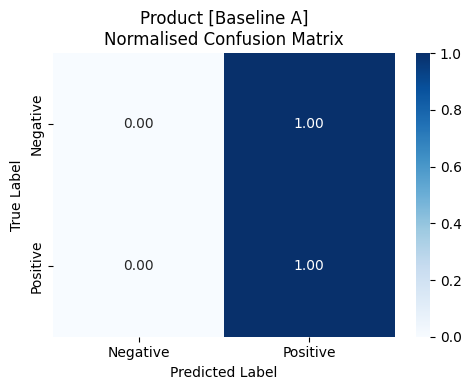

  Confusion matrix saved -> /home/levizenith/SednaAI/cache_hlc/product_baseline_a_cm.png

--- SERVICE ---


              precision    recall  f1-score   support

    Negative     0.0000    0.0000    0.0000        15
    Positive     0.9690    1.0000    0.9843       469

    accuracy                         0.9690       484
   macro avg     0.4845    0.5000    0.4921       484
weighted avg     0.9390    0.9690    0.9538       484



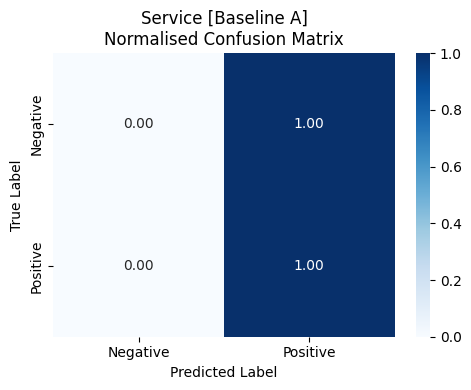

  Confusion matrix saved -> /home/levizenith/SednaAI/cache_hlc/service_baseline_a_cm.png

Baseline A results cached.


In [16]:
# ── Baseline A: pre-trained backbone, random classification head ──────────────
print('=' * 55)
print('Baseline A — Pre-trained Only (Random Head)')
print('=' * 55)

_baseline_a = SentimentClassifier().to(device)
_baseline_a.eval()
for p in _baseline_a.parameters():
    p.requires_grad = False

baseline_a_results = {}
for ds_name, loader, data in [
    ('product', product_loaders['test'], product_data),
    ('service', service_loaders['test'], service_data),
]:
    print(f'\n--- {ds_name.upper()} ---')
    res = evaluate(_baseline_a, loader, device, desc=f'Baseline A [{ds_name}]')
    baseline_a_results[ds_name] = res
    print(res['report'])
    plot_confusion_matrix(res['all_labels'], res['all_preds'],
                          ds_name.capitalize(), 'Baseline A')

with open(os.path.join(CACHE_DIR, 'baseline_a_results.pkl'), 'wb') as fh:
    pickle.dump(baseline_a_results, fh)
print('\nBaseline A results cached.')

del _baseline_a
torch.cuda.empty_cache()

Baseline B — Amazon Zero-Shot (No Domain Adaptation)
Amazon DeBERTa loaded and frozen.

--- PRODUCT ---


              precision    recall  f1-score   support

    Negative     0.7500    0.9000    0.8182        10
    Positive     1.0000    0.8971    0.9457       408

   micro avg     0.9921    0.8971    0.9422       418
   macro avg     0.8750    0.8985    0.8820       418
weighted avg     0.9940    0.8971    0.9427       418



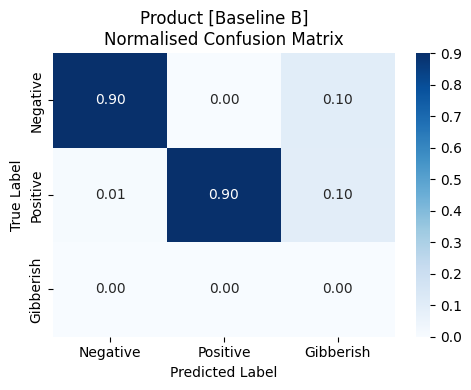

  Confusion matrix saved -> /home/levizenith/SednaAI/cache_hlc/product_baseline_b_cm.png

Product [Baseline B] — misclassified: 43 samples
    index true_label pred_label  confidence                                                                                                         comment
0    1043   Positive  Gibberish      0.9491                                                                           Lovex the space theme lovely quality 
1    2250   Positive  Gibberish      0.8906                                                                                       Lovely bedding very cute 
2    2402   Positive  Gibberish      0.8730                                                                                       Soft attractive material 
3    2198   Positive  Gibberish      0.8702                                                                                             Beautiful bed linen
4    1366   Positive  Gibberish      0.8656                                      

              precision    recall  f1-score   support

    Negative     0.7000    0.9333    0.8000        15
    Positive     0.9977    0.9382    0.9670       469

   micro avg     0.9848    0.9380    0.9608       484
   macro avg     0.8489    0.9357    0.8835       484
weighted avg     0.9885    0.9380    0.9619       484



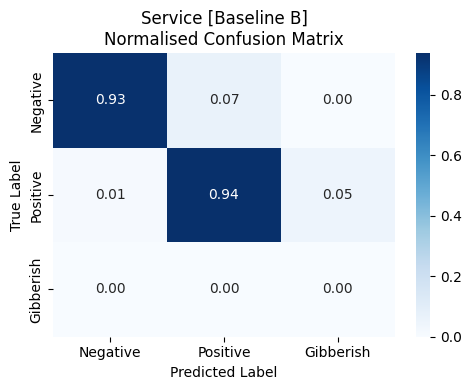

  Confusion matrix saved -> /home/levizenith/SednaAI/cache_hlc/service_baseline_b_cm.png

Service [Baseline B] — misclassified: 30 samples
    index true_label pred_label  confidence                                                                                                                                                                                                                                                                                                       comment
0     230   Positive   Negative      0.9802  Not as vibrant in colour When the duvet cover and fitted sheets arrived for my granddaughter I was a little disappointed in the quality of the material it was quite thin and also the colours on the cover were not as vibrant as they appeared on line. Hence you always pay for what you get. I would hav
1      62   Negative   Positive      0.9470                                                                                                                              

In [17]:
# ── Baseline B: Amazon zero-shot (no HLC adaptation) ─────────────────────────
print('=' * 55)
print('Baseline B — Amazon Zero-Shot (No Domain Adaptation)')
print('=' * 55)

_baseline_b = load_amazon_model(AMAZON_MODEL_PATH, device)

baseline_b_results = {}
for ds_name, loader, data in [
    ('product', product_loaders['test'], product_data),
    ('service', service_loaders['test'], service_data),
]:
    print(f'\n--- {ds_name.upper()} ---')
    res = evaluate(_baseline_b, loader, device, desc=f'Baseline B [{ds_name}]')
    baseline_b_results[ds_name] = res
    print(res['report'])
    plot_confusion_matrix(res['all_labels'], res['all_preds'],
                          ds_name.capitalize(), 'Baseline B')
    misclassification_report(
        res['all_labels'], res['all_preds'], res['all_probs'],
        data['test']['text'].tolist(),
        ds_name.capitalize(), 'Baseline B',
        orig_indices=data['test'].index.tolist()
    )

with open(os.path.join(CACHE_DIR, 'baseline_b_results.pkl'), 'wb') as fh:
    pickle.dump(baseline_b_results, fh)
print('\nBaseline B results cached.')

del _baseline_b
torch.cuda.empty_cache()

---

## Section 8 — Transfer Learning Training

Amazon DeBERTa backbone is loaded and frozen; only the classification head `fc`
(~2,307 parameters) is updated.

- Product and Service are trained **independently** — no shared head weights
- Each call to `train_hlc` reloads from the Amazon checkpoint, so both starts are identical
- Early stopping patience: `EARLY_STOP_PATIENCE = 3`
- Best checkpoint (lowest val loss) saved to the notebook directory

In [18]:
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    '''
    Execute one training epoch and return mean loss and accuracy.

    Parameters
    ----------
    model     : SentimentClassifier
    loader    : DataLoader  (training split)
    optimizer : torch.optim.Optimizer
    loss_fn   : nn.CrossEntropyLoss
    device    : torch.device

    Returns
    -------
    avg_loss : float  Mean cross-entropy loss over all batches.
    avg_acc  : float  Mean classification accuracy over all batches.
    '''
    model.train()
    total_loss, correct, n = 0.0, 0, 0

    for batch in tqdm(loader, desc='    Train', leave=False):
        ids    = batch['input_ids'].to(device)
        mask   = batch['attention_mask'].to(device)
        labs   = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = model(ids, mask)
        loss   = loss_fn(logits, labs)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += (logits.argmax(1) == labs).sum().item()
        n          += labs.size(0)

    return total_loss / len(loader), correct / n


def train_hlc(dataset_name, train_loader, val_loader, class_weights, save_path):
    '''
    Full transfer learning pipeline: load Amazon weights -> freeze backbone
    -> train classification head with early stopping.

    Parameters
    ----------
    dataset_name  : str             'Product' or 'Service' (used for logging and cache).
    train_loader  : DataLoader
    val_loader    : DataLoader
    class_weights : torch.Tensor    Shape (num_classes,) class weights for loss.
    save_path     : str             Path to save the best checkpoint (.pt).

    Returns
    -------
    history : dict  Keys: 'train_loss', 'val_loss', 'train_acc', 'val_acc' (lists).

    Notes
    -----
    - Reloads from AMAZON_MODEL_PATH on every call; Product and Service training
      are fully independent.
    - Training history is cached to cache_hlc/{dataset_name}_history.pkl.
    '''
    model = SentimentClassifier().to(device)
    state = torch.load(AMAZON_MODEL_PATH, map_location=device)
    if any(k.startswith('selected_transformer') for k in state):
        state = {k.replace('selected_transformer', 'encoder', 1): v
                 for k, v in state.items()}
    model.load_state_dict(state)
    freeze_backbone(model)

    optimizer = torch.optim.AdamW(model.fc.parameters(),
                                  lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn   = nn.CrossEntropyLoss(weight=class_weights)

    history    = {'train_loss': [], 'val_loss': [],
                  'train_acc':  [], 'val_acc':  []}
    best_val   = float('inf')
    no_improve = 0

    print(f'\n{"=" * 55}')
    print(f'Training: {dataset_name}  |  max {MAX_EPOCHS} epochs  |  patience {EARLY_STOP_PATIENCE}')
    print(f'{"=" * 55}')

    for epoch in range(MAX_EPOCHS):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        val_res         = evaluate(model, val_loader, device, loss_fn,
                                   desc=f'Val e{epoch+1:02d}')
        vl_loss         = val_res['loss']

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_res['weighted_f1'])

        flag = ''
        if vl_loss < best_val:
            best_val   = vl_loss
            no_improve = 0
            torch.save(model.state_dict(), save_path)
            flag = '  <- best'
        else:
            no_improve += 1
            flag = f'  (no improve {no_improve}/{EARLY_STOP_PATIENCE})'

        print(f'  Epoch {epoch+1:02d}/{MAX_EPOCHS} | '
              f'Train Loss {tr_loss:.4f}  Acc {tr_acc:.4f} | '
              f'Val Loss {vl_loss:.4f}  W-F1 {val_res["weighted_f1"]:.4f}{flag}')

        if no_improve >= EARLY_STOP_PATIENCE:
            print(f'  Early stopping triggered at epoch {epoch+1}.')
            break

    cache_path = os.path.join(CACHE_DIR, f'{dataset_name.lower()}_history.pkl')
    with open(cache_path, 'wb') as fh:
        pickle.dump(history, fh)
    print(f'  History cached -> {cache_path}')

    del model
    torch.cuda.empty_cache()
    return history


Backbone frozen. Trainable parameters: 2,307

Training: Product  |  max 20 epochs  |  patience 3


  Epoch 01/20 | Train Loss 0.1641  Acc 0.9794 | Val Loss 0.0302  W-F1 0.9912  <- best


  Epoch 02/20 | Train Loss 0.1623  Acc 0.9877 | Val Loss 0.0216  W-F1 0.9933  <- best


  Epoch 03/20 | Train Loss 0.1392  Acc 0.9877 | Val Loss 0.0297  W-F1 0.9933  (no improve 1/3)


  Epoch 04/20 | Train Loss 0.1045  Acc 0.9918 | Val Loss 0.0161  W-F1 0.9933  <- best


  Epoch 05/20 | Train Loss 0.1335  Acc 0.9897 | Val Loss 0.0193  W-F1 0.9933  (no improve 1/3)


  Epoch 06/20 | Train Loss 0.1269  Acc 0.9892 | Val Loss 0.0220  W-F1 0.9933  (no improve 2/3)


  Epoch 07/20 | Train Loss 0.1126  Acc 0.9892 | Val Loss 0.0284  W-F1 0.9933  (no improve 3/3)
  Early stopping triggered at epoch 7.
  History cached -> /home/levizenith/SednaAI/cache_hlc/product_history.pkl

Best checkpoint saved -> /home/levizenith/SednaAI/DeBERTa_HLC_Product_best.pt


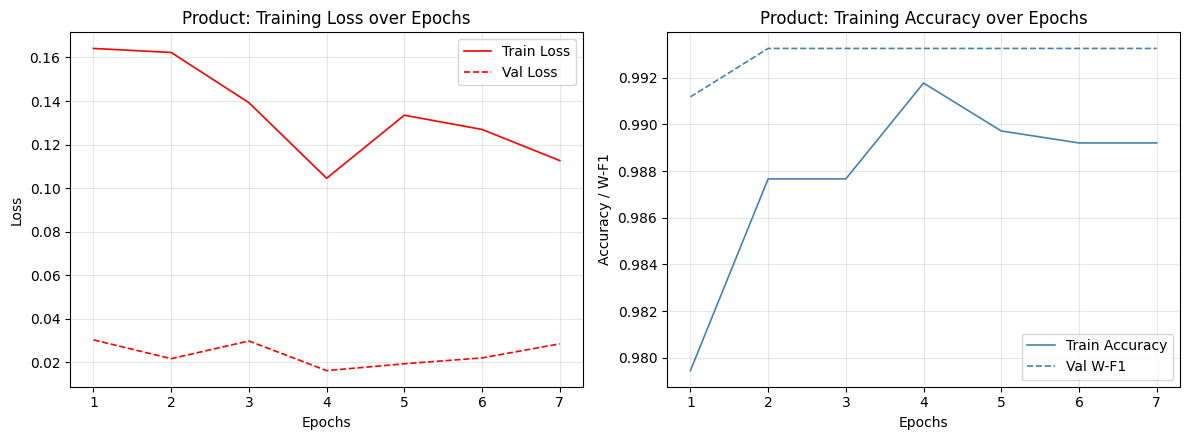

  Training curves saved -> /home/levizenith/SednaAI/cache_hlc/product_training_curves.png


In [19]:
# ── Train: Product Reviews ────────────────────────────────────────────────────
product_save    = os.path.join(BASE_DIR, 'DeBERTa_HLC_Product_best.pt')
product_history = train_hlc(
    dataset_name  = 'Product',
    train_loader  = product_loaders['train'],
    val_loader    = product_loaders['val'],
    class_weights = product_data['class_weights'],
    save_path     = product_save
)
print(f'\nBest checkpoint saved -> {product_save}')
plot_training_curves(product_history, 'Product')

Backbone frozen. Trainable parameters: 2,307

Training: Service  |  max 20 epochs  |  patience 3


  Epoch 01/20 | Train Loss 0.0795  Acc 0.9885 | Val Loss 0.0167  W-F1 0.9941  <- best


  Epoch 02/20 | Train Loss 0.0715  Acc 0.9916 | Val Loss 0.0514  W-F1 0.9869  (no improve 1/3)


  Epoch 03/20 | Train Loss 0.0497  Acc 0.9925 | Val Loss 0.0208  W-F1 0.9959  (no improve 2/3)


  Epoch 04/20 | Train Loss 0.0588  Acc 0.9920 | Val Loss 0.0215  W-F1 0.9922  (no improve 3/3)
  Early stopping triggered at epoch 4.
  History cached -> /home/levizenith/SednaAI/cache_hlc/service_history.pkl

Best checkpoint saved -> /home/levizenith/SednaAI/DeBERTa_HLC_Service_best.pt


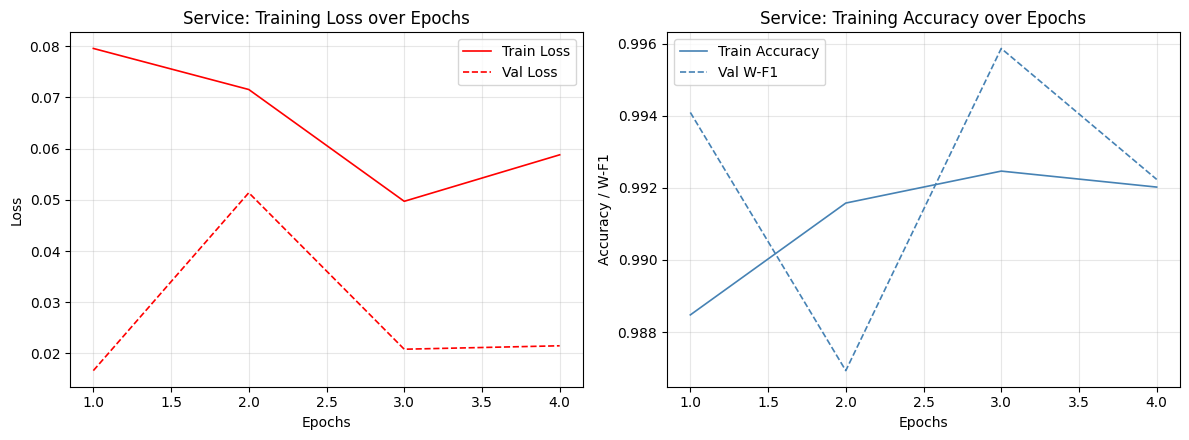

  Training curves saved -> /home/levizenith/SednaAI/cache_hlc/service_training_curves.png


In [20]:
# ── Train: Service Reviews ────────────────────────────────────────────────────
service_save    = os.path.join(BASE_DIR, 'DeBERTa_HLC_Service_best.pt')
service_history = train_hlc(
    dataset_name  = 'Service',
    train_loader  = service_loaders['train'],
    val_loader    = service_loaders['val'],
    class_weights = service_data['class_weights'],
    save_path     = service_save
)
print(f'\nBest checkpoint saved -> {service_save}')
plot_training_curves(service_history, 'Service')

---

## Section 9 — Post-Adaptation Evaluation

Load the best checkpoint for each dataset and evaluate on the held-out test set.
Outputs: classification report, normalised confusion matrix, and misclassification
table sorted by prediction confidence.

Adapted — Product Reviews



              precision    recall  f1-score   support

    Negative     0.9000    0.9000    0.9000        10
    Positive     0.9975    0.9975    0.9975       408

    accuracy                         0.9952       418
   macro avg     0.9488    0.9488    0.9488       418
weighted avg     0.9952    0.9952    0.9952       418



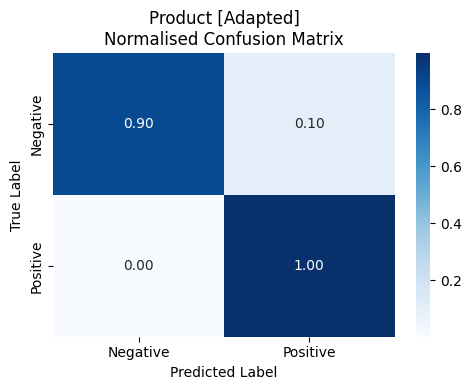

  Confusion matrix saved -> /home/levizenith/SednaAI/cache_hlc/product_adapted_cm.png

Product [Adapted] — misclassified: 2 samples
   index true_label pred_label  confidence                                                               comment
0     35   Negative   Positive      0.9989                                 Well made.pwcaged in matching toy bag
1   2686   Positive   Negative      0.8384  Is what it says, was a free gift with my order donated it to nursery
  Misclassification table saved -> /home/levizenith/SednaAI/cache_hlc/product_adapted_misclassified.csv

Adapted Product results cached.


In [21]:
# ── Evaluate: Product Reviews (Adapted) ──────────────────────────────────────
print('=' * 55)
print('Adapted — Product Reviews')
print('=' * 55)

_adapted_product = SentimentClassifier().to(device)
_adapted_product.load_state_dict(torch.load(product_save, map_location=device))
_adapted_product.eval()

adapted_product_results = evaluate(
    _adapted_product, product_loaders['test'], device,
    desc='Test [Product Adapted]'
)
print('\n' + adapted_product_results['report'])

plot_confusion_matrix(adapted_product_results['all_labels'],
                      adapted_product_results['all_preds'],
                      'Product', 'Adapted')

product_mis = misclassification_report(
    adapted_product_results['all_labels'],
    adapted_product_results['all_preds'],
    adapted_product_results['all_probs'],
    product_data['test']['text'].tolist(),
    'Product', 'Adapted',
    orig_indices=product_data['test'].index.tolist()
)

with open(os.path.join(CACHE_DIR, 'adapted_product_results.pkl'), 'wb') as fh:
    pickle.dump(adapted_product_results, fh)
print('\nAdapted Product results cached.')

del _adapted_product
torch.cuda.empty_cache()

Adapted — Service Reviews



              precision    recall  f1-score   support

    Negative     0.8235    0.9333    0.8750        15
    Positive     0.9979    0.9936    0.9957       469

    accuracy                         0.9917       484
   macro avg     0.9107    0.9635    0.9354       484
weighted avg     0.9925    0.9917    0.9920       484



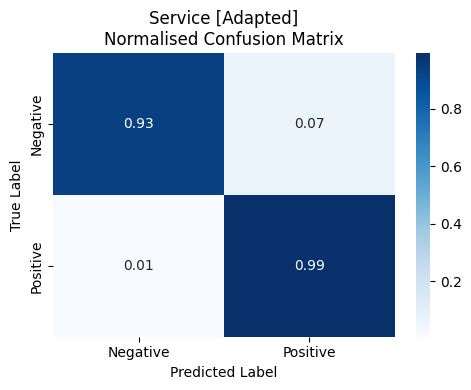

  Confusion matrix saved -> /home/levizenith/SednaAI/cache_hlc/service_adapted_cm.png

Service [Adapted] — misclassified: 4 samples
   index true_label pred_label  confidence                                                                                                                                                                                                                                                                                                       comment
0     62   Negative   Positive      0.9998                                                                                                                                                                                                                              Excellent service and the goods are… Excellent service and the goods are lovely.
1    230   Positive   Negative      0.9971  Not as vibrant in colour When the duvet cover and fitted sheets arrived for my granddaughter I was a little disappointed in the qualit

In [22]:
# ── Evaluate: Service Reviews (Adapted) ──────────────────────────────────────
print('=' * 55)
print('Adapted — Service Reviews')
print('=' * 55)

_adapted_service = SentimentClassifier().to(device)
_adapted_service.load_state_dict(torch.load(service_save, map_location=device))
_adapted_service.eval()

adapted_service_results = evaluate(
    _adapted_service, service_loaders['test'], device,
    desc='Test [Service Adapted]'
)
print('\n' + adapted_service_results['report'])

plot_confusion_matrix(adapted_service_results['all_labels'],
                      adapted_service_results['all_preds'],
                      'Service', 'Adapted')

service_mis = misclassification_report(
    adapted_service_results['all_labels'],
    adapted_service_results['all_preds'],
    adapted_service_results['all_probs'],
    service_data['test']['text'].tolist(),
    'Service', 'Adapted',
    orig_indices=service_data['test'].index.tolist()
)

with open(os.path.join(CACHE_DIR, 'adapted_service_results.pkl'), 'wb') as fh:
    pickle.dump(adapted_service_results, fh)
print('\nAdapted Service results cached.')

del _adapted_service
torch.cuda.empty_cache()

---

## Section 10 — Summary Comparison

Three-condition × two-dataset × four-metric comparison table.

| Condition | Description |
|-----------|-------------|
| Baseline A | Pre-trained backbone only, random head, no fine-tuning |
| Baseline B | Amazon fine-tuned DeBERTa, zero-shot on HLC |
| Adapted | Amazon backbone frozen + HLC classification head fine-tuned |

The delta row shows the gain from domain adaptation (Adapted − Baseline B).

In [23]:
def build_summary_table(baseline_a, baseline_b, adapted_product, adapted_service):
    '''
    Construct a three-condition comparison table from evaluation result dicts.

    Parameters
    ----------
    baseline_a      : dict  {'product': eval_dict, 'service': eval_dict}
    baseline_b      : dict  Same structure.
    adapted_product : dict  Single-dataset eval_dict for Product (Adapted).
    adapted_service : dict  Single-dataset eval_dict for Service (Adapted).

    Returns
    -------
    summary : pd.DataFrame
        Rows: three conditions.
        Columns: (dataset x metric) — W-F1, Neg-F1, Pos-F1, Gibb-F1 for each dataset.
    '''
    def extract(res):
        pcf = res['per_class_f1']
        return {
            'W-F1':    round(res['weighted_f1'],         4),
            'Neg-F1':  round(pcf.get('Negative',  0.0), 4),
            'Pos-F1':  round(pcf.get('Positive',  0.0), 4),
            'Gibb-F1': round(pcf.get('Gibberish', 0.0), 4),
        }

    conditions = {
        'Baseline A (Pre-trained Only)': {'product': baseline_a['product'],
                                           'service': baseline_a['service']},
        'Baseline B (Amazon Zero-Shot)': {'product': baseline_b['product'],
                                           'service': baseline_b['service']},
        'Adapted (Transfer Learning)':   {'product': adapted_product,
                                           'service': adapted_service},
    }

    rows = []
    for cond, datasets in conditions.items():
        row = {'Condition': cond}
        for ds in ['product', 'service']:
            for k, v in extract(datasets[ds]).items():
                row[f'{ds.capitalize()} {k}'] = v
        rows.append(row)

    summary = pd.DataFrame(rows).set_index('Condition')

    print('\n' + '=' * 55)
    print('SUMMARY TABLE')
    print('=' * 55)
    print(summary.to_string())

    delta = (summary.loc['Adapted (Transfer Learning)'] -
             summary.loc['Baseline B (Amazon Zero-Shot)'])
    print('\n' + '-' * 55)
    print('Transfer learning gain  (Adapted - Baseline B)')
    print('-' * 55)
    print(delta.to_string())

    cache_path = os.path.join(CACHE_DIR, 'summary_table.csv')
    summary.to_csv(cache_path, encoding='utf-8-sig')
    print(f'\nSummary table cached -> {cache_path}')
    return summary


summary = build_summary_table(
    baseline_a_results,
    baseline_b_results,
    adapted_product_results,
    adapted_service_results
)


SUMMARY TABLE
                               Product W-F1  Product Neg-F1  Product Pos-F1  Product Gibb-F1  Service W-F1  Service Neg-F1  Service Pos-F1  Service Gibb-F1
Condition                                                                                                                                                  
Baseline A (Pre-trained Only)        0.9643          0.0000          0.9879              0.0        0.9538           0.000          0.9843              0.0
Baseline B (Amazon Zero-Shot)        0.9427          0.8182          0.9457              0.0        0.9619           0.800          0.9670              0.0
Adapted (Transfer Learning)          0.9952          0.9000          0.9975              0.0        0.9920           0.875          0.9957              0.0

-------------------------------------------------------
Transfer learning gain  (Adapted - Baseline B)
-------------------------------------------------------
Product W-F1       0.0525
Product Neg-F1     

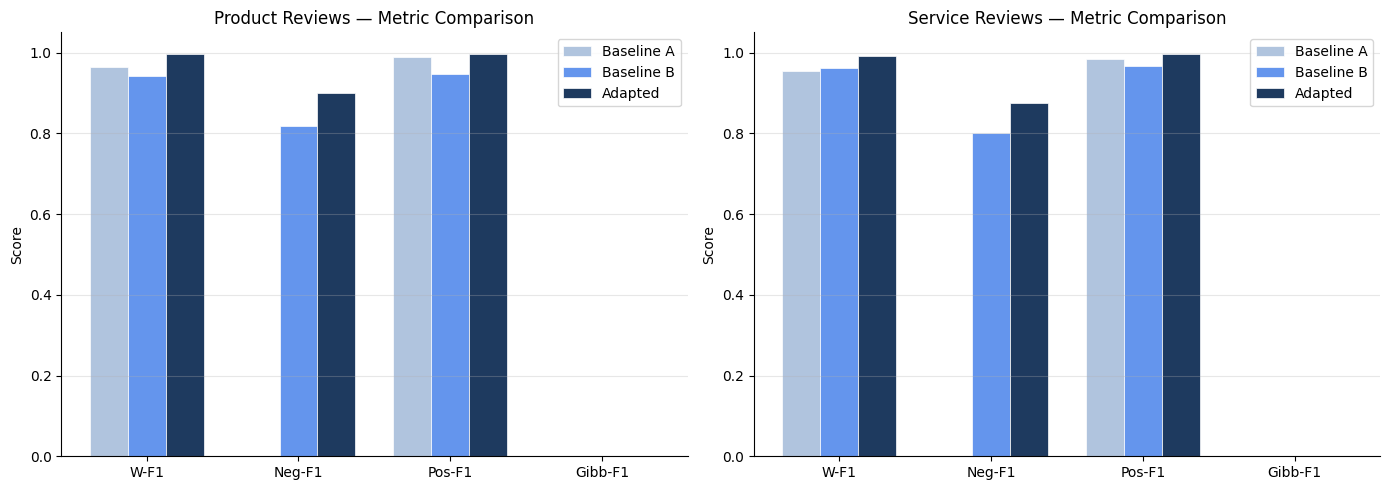

Summary bar chart saved -> /home/levizenith/SednaAI/cache_hlc/summary_bar_chart.png


In [24]:
def plot_summary_bars(summary):
    '''
    Grouped bar chart comparing three conditions across four metrics for each dataset.

    Parameters
    ----------
    summary : pd.DataFrame  Output of build_summary_table().
    '''
    metrics  = ['W-F1', 'Neg-F1', 'Pos-F1', 'Gibb-F1']
    datasets = ['Product', 'Service']
    colors   = ['#b0c4de', '#6495ed', '#1e3a5f']
    labels   = ['Baseline A', 'Baseline B', 'Adapted']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    for ax, ds in zip(axes, datasets):
        cols = [f'{ds} {m}' for m in metrics]
        vals = summary[cols].values       # shape (3, 4)
        x    = np.arange(len(metrics))
        w    = 0.25

        for i, (label, color) in enumerate(zip(labels, colors)):
            ax.bar(x + i * w, vals[i], width=w, label=label,
                   color=color, edgecolor='white', linewidth=0.5)

        ax.set_title(f'{ds} Reviews — Metric Comparison')
        ax.set_xticks(x + w)
        ax.set_xticklabels(metrics)
        ax.set_ylabel('Score')
        ax.set_ylim(0, 1.05)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

    plt.tight_layout()
    save_path = os.path.join(CACHE_DIR, 'summary_bar_chart.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Summary bar chart saved -> {save_path}')


plot_summary_bars(summary)

In [25]:
print('=' * 55)
print('All sections complete.')
print(f'Cached outputs -> {CACHE_DIR}')
print('  Training curves     : *_training_curves.png')
print('  Confusion matrices  : *_cm.png')
print('  Misclassified CSV   : *_misclassified.csv')
print('  Summary table       : summary_table.csv')
print('  Summary bar chart   : summary_bar_chart.png')
print('  Model checkpoints   : DeBERTa_HLC_Product_best.pt')
print('                        DeBERTa_HLC_Service_best.pt')
print('=' * 55)

All sections complete.
Cached outputs -> /home/levizenith/SednaAI/cache_hlc
  Training curves     : *_training_curves.png
  Confusion matrices  : *_cm.png
  Misclassified CSV   : *_misclassified.csv
  Summary table       : summary_table.csv
  Summary bar chart   : summary_bar_chart.png
  Model checkpoints   : DeBERTa_HLC_Product_best.pt
                        DeBERTa_HLC_Service_best.pt


---

## Section 11 — Full Fine-Tuning

Instead of freezing the DeBERTa backbone and training only the classification head,
this section fine-tunes **all model parameters** end-to-end.

Key differences from the head-only approach (Section 8):

| Setting | Head-Only (§8) | Full Fine-Tuning (§11) |
|---|---|---|
| Trainable params | ~2 307 (head only) | ~86 M (entire model) |
| Learning rate | 1e-3 | 2e-5 |
| Overfitting risk | Low | Higher (3 k samples) |
| Domain adaptation | None (frozen repr.) | Full |

The lower learning rate (2e-5) follows standard practice for fine-tuning large
pre-trained transformers; larger values cause catastrophic forgetting.
Early stopping (patience = 3) on validation loss guards against overfitting.

Both datasets are trained independently, starting from the same Amazon checkpoint.


In [26]:
LR_FULL           = 2e-5   # much lower than head-only LR to avoid catastrophic forgetting
WEIGHT_DECAY_FULL = 1e-2


def train_hlc_full(dataset_name, train_loader, val_loader, class_weights, save_path):
    '''
    Full-parameter fine-tuning pipeline: load Amazon weights -> train ALL parameters
    with a low learning rate and early stopping.

    Parameters
    ----------
    dataset_name  : str             'Product' or 'Service'.
    train_loader  : DataLoader
    val_loader    : DataLoader
    class_weights : torch.Tensor    Shape (num_classes,) class weights for loss.
    save_path     : str             Path to save the best checkpoint (.pt).

    Returns
    -------
    history : dict  Keys: 'train_loss', 'val_loss', 'train_acc', 'val_acc'.

    Notes
    -----
    - Unlike train_hlc(), the backbone is NOT frozen; all ~86 M parameters are updated.
    - LR_FULL = 2e-5 prevents catastrophic forgetting of pre-trained representations.
    - History cached to cache_hlc/{dataset_name.lower()}_full_history.pkl.
    '''
    model = SentimentClassifier().to(device)
    _ckpt = torch.load(AMAZON_MODEL_PATH, map_location=device)
    if any(k.startswith('selected_transformer.') for k in _ckpt):
        _ckpt = {k.replace('selected_transformer.', 'encoder.'): v for k, v in _ckpt.items()}
    model.load_state_dict(_ckpt)
    # No freeze — all parameters are trainable

    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=LR_FULL, weight_decay=WEIGHT_DECAY_FULL)
    loss_fn   = nn.CrossEntropyLoss(weight=class_weights)

    history    = {'train_loss': [], 'val_loss': [],
                  'train_acc':  [], 'val_acc':  []}
    best_val   = float('inf')
    no_improve = 0

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'\n{"=" * 55}')
    print(f'Full Fine-Tuning: {dataset_name}  |  trainable params: {trainable:,}')
    print(f'LR={LR_FULL}  |  max {MAX_EPOCHS} epochs  |  patience {EARLY_STOP_PATIENCE}')
    print(f'{"=" * 55}')

    for epoch in range(MAX_EPOCHS):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        val_res         = evaluate(model, val_loader, device, loss_fn,
                                   desc=f'Val e{epoch+1:02d}')
        vl_loss         = val_res['loss']

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_res['weighted_f1'])

        flag = ''
        if vl_loss < best_val:
            best_val   = vl_loss
            no_improve = 0
            torch.save(model.state_dict(), save_path)
            flag = '  <- best'
        else:
            no_improve += 1
            flag = f'  (no improve {no_improve}/{EARLY_STOP_PATIENCE})'

        print(f'  Epoch {epoch+1:02d}/{MAX_EPOCHS} | '
              f'Train Loss {tr_loss:.4f}  Acc {tr_acc:.4f} | '
              f'Val Loss {vl_loss:.4f}  W-F1 {val_res["weighted_f1"]:.4f}{flag}')

        if no_improve >= EARLY_STOP_PATIENCE:
            print(f'  Early stopping triggered at epoch {epoch+1}.')
            break

    cache_path = os.path.join(CACHE_DIR, f'{dataset_name.lower()}_full_history.pkl')
    with open(cache_path, 'wb') as fh:
        pickle.dump(history, fh)
    print(f'  History cached -> {cache_path}')

    del model
    torch.cuda.empty_cache()
    return history


[Cache] Loading Product full history from /home/levizenith/SednaAI/cache_hlc/product_full_history.pkl


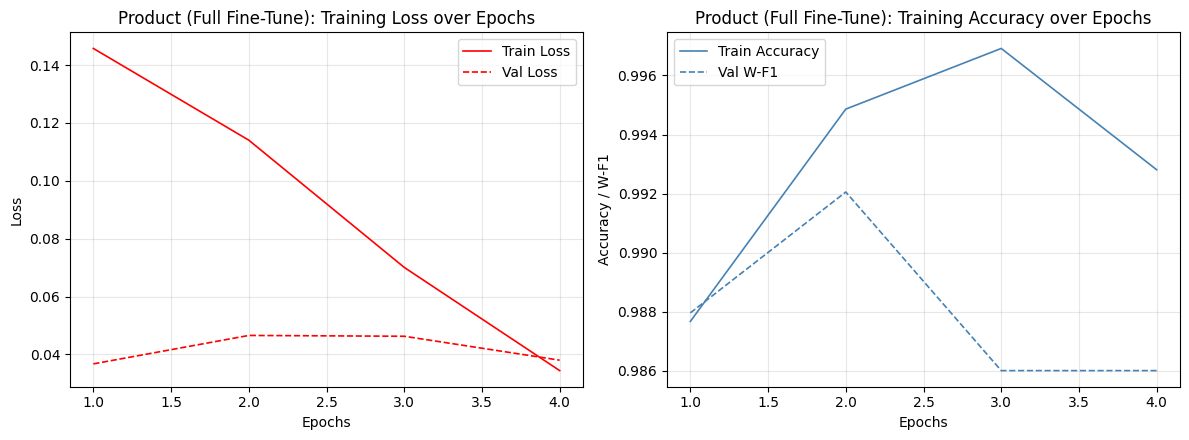

  Training curves saved -> /home/levizenith/SednaAI/cache_hlc/product (full fine-tune)_training_curves.png


In [27]:
# -- Train: Product Reviews (Full Fine-Tuning) ---------------------------------
product_full_save         = os.path.join(BASE_DIR, 'DeBERTa_HLC_Product_full_best.pt')
product_full_history_path = os.path.join(CACHE_DIR, 'product_full_history.pkl')

if os.path.exists(product_full_history_path):
    print(f'[Cache] Loading Product full history from {product_full_history_path}')
    with open(product_full_history_path, 'rb') as fh:
        product_full_history = pickle.load(fh)
else:
    product_full_history = train_hlc_full(
        dataset_name  = 'Product',
        train_loader  = product_loaders['train'],
        val_loader    = product_loaders['val'],
        class_weights = product_data['class_weights'],
        save_path     = product_full_save
    )
    print(f'\nBest checkpoint saved -> {product_full_save}')

plot_training_curves(product_full_history, 'Product (Full Fine-Tune)')



Full Fine-Tuning: Service  |  trainable params: 183,833,859
LR=2e-05  |  max 20 epochs  |  patience 3


  Epoch 01/20 | Train Loss 0.0581  Acc 0.9907 | Val Loss 0.0160  W-F1 0.9960  <- best


  Epoch 02/20 | Train Loss 0.0414  Acc 0.9956 | Val Loss 0.0348  W-F1 0.9852  (no improve 1/3)


  Epoch 03/20 | Train Loss 0.0339  Acc 0.9987 | Val Loss 0.0384  W-F1 0.9904  (no improve 2/3)


  Epoch 04/20 | Train Loss 0.0039  Acc 1.0000 | Val Loss 0.0354  W-F1 0.9904  (no improve 3/3)
  Early stopping triggered at epoch 4.
  History cached -> /home/levizenith/SednaAI/cache_hlc/service_full_history.pkl

Best checkpoint saved -> /home/levizenith/SednaAI/DeBERTa_HLC_Service_full_best.pt


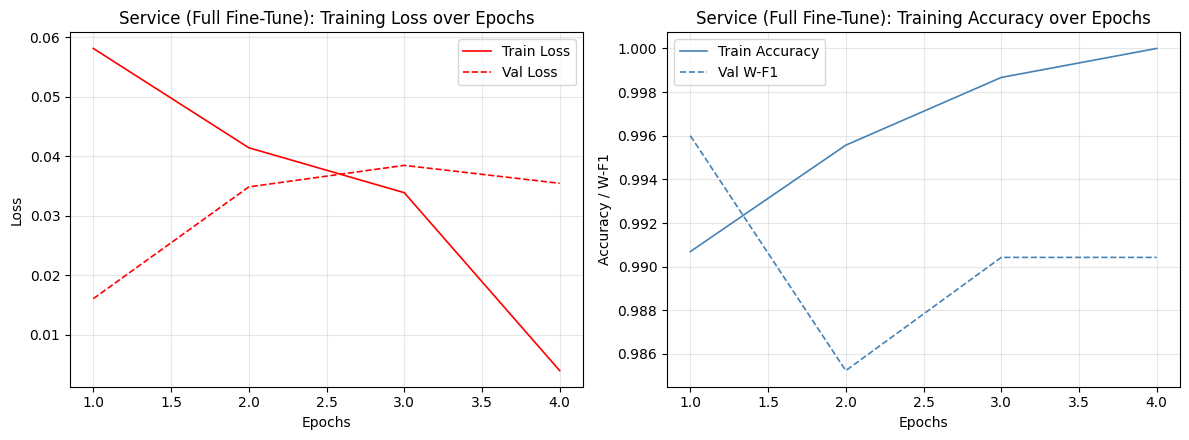

  Training curves saved -> /home/levizenith/SednaAI/cache_hlc/service (full fine-tune)_training_curves.png


In [28]:
# -- Train: Service Reviews (Full Fine-Tuning) ---------------------------------
service_full_save         = os.path.join(BASE_DIR, 'DeBERTa_HLC_Service_full_best.pt')
service_full_history_path = os.path.join(CACHE_DIR, 'service_full_history.pkl')

if os.path.exists(service_full_history_path):
    print(f'[Cache] Loading Service full history from {service_full_history_path}')
    with open(service_full_history_path, 'rb') as fh:
        service_full_history = pickle.load(fh)
else:
    service_full_history = train_hlc_full(
        dataset_name  = 'Service',
        train_loader  = service_loaders['train'],
        val_loader    = service_loaders['val'],
        class_weights = service_data['class_weights'],
        save_path     = service_full_save
    )
    print(f'\nBest checkpoint saved -> {service_full_save}')

plot_training_curves(service_full_history, 'Service (Full Fine-Tune)')


---

## Section 12 — Post-Full-Tuning Evaluation

Load the best full-fine-tuned checkpoint for each dataset and evaluate on the held-out
test set. Results are cached and a misclassification report is generated.


Full Fine-Tuned -- Product Reviews


Results cached -> /home/levizenith/SednaAI/cache_hlc/product_full_results.pkl

              precision    recall  f1-score   support

    Negative     1.0000    0.9000    0.9474        10
    Positive     0.9976    1.0000    0.9988       408

    accuracy                         0.9976       418
   macro avg     0.9988    0.9500    0.9731       418
weighted avg     0.9976    0.9976    0.9975       418



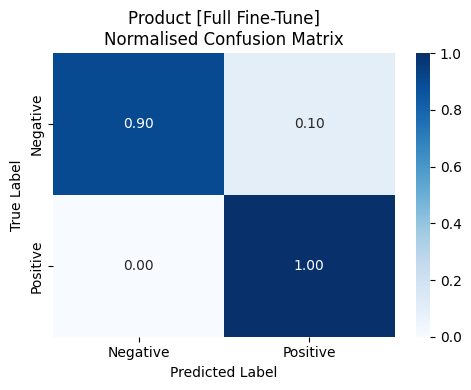

  Confusion matrix saved -> /home/levizenith/SednaAI/cache_hlc/product_full_fine-tune_cm.png

Product [Full Fine-Tune] — misclassified: 1 samples
   index true_label pred_label  confidence                                comment
0     35   Negative   Positive      0.9769  Well made.pwcaged in matching toy bag
  Misclassification table saved -> /home/levizenith/SednaAI/cache_hlc/product_full_fine-tune_misclassified.csv


,index,true_label,pred_label,confidence,comment
0,35,Negative,Positive,0.9769,Well made.pwcaged in matching toy bag


In [29]:
# -- Evaluate: Product Reviews (Full Fine-Tuned) -------------------------------
print('=' * 55)
print('Full Fine-Tuned -- Product Reviews')
print('=' * 55)

_cache_full_product = os.path.join(CACHE_DIR, 'product_full_results.pkl')

if os.path.exists(_cache_full_product):
    print(f'[Cache] Loading from {_cache_full_product}')
    with open(_cache_full_product, 'rb') as fh:
        full_product_results = pickle.load(fh)
else:
    _full_product = SentimentClassifier().to(device)
    _full_product.load_state_dict(torch.load(product_full_save, map_location=device))
    _full_product.eval()

    full_product_results = evaluate(
        _full_product, product_loaders['test'], device,
        desc='Test [Product Full]'
    )
    with open(_cache_full_product, 'wb') as fh:
        pickle.dump(full_product_results, fh)
    print(f'Results cached -> {_cache_full_product}')
    del _full_product
    torch.cuda.empty_cache()

print('\n' + full_product_results['report'])

plot_confusion_matrix(full_product_results['all_labels'],
                      full_product_results['all_preds'],
                      'Product', 'Full Fine-Tune')

full_product_mis = misclassification_report(
    full_product_results['all_labels'],
    full_product_results['all_preds'],
    full_product_results['all_probs'],
    product_data['test']['text'].tolist(),
    dataset_name='Product',
    condition='Full Fine-Tune',
    orig_indices=product_data['test'].index.tolist()
)


Full Fine-Tuned -- Service Reviews


Results cached -> /home/levizenith/SednaAI/cache_hlc/service_full_results.pkl

              precision    recall  f1-score   support

    Negative     0.8235    0.9333    0.8750        15
    Positive     0.9979    0.9936    0.9957       469

    accuracy                         0.9917       484
   macro avg     0.9107    0.9635    0.9354       484
weighted avg     0.9925    0.9917    0.9920       484



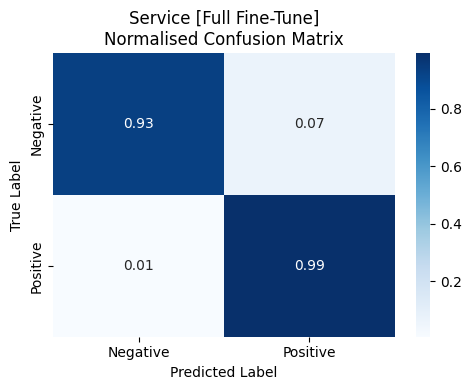

  Confusion matrix saved -> /home/levizenith/SednaAI/cache_hlc/service_full_fine-tune_cm.png

Service [Full Fine-Tune] — misclassified: 4 samples
   index true_label pred_label  confidence                                                                                                                                                                                                                                                                                                       comment
0     62   Negative   Positive      0.9984                                                                                                                                                                                                                              Excellent service and the goods are… Excellent service and the goods are lovely.
1    230   Positive   Negative      0.9973  Not as vibrant in colour When the duvet cover and fitted sheets arrived for my granddaughter I was a little disappointed

,index,true_label,pred_label,confidence,comment
0,62,Negative,Positive,0.9984,Excellent service and the goods are… Excellent...
1,230,Positive,Negative,0.9973,Not as vibrant in colour When the duvet cover ...
2,2980,Positive,Negative,0.7459,Item arrived on time but not opened yet… Item ...
3,810,Positive,Negative,0.7045,Make sure you are ordering the correct goods Q...


In [30]:
# -- Evaluate: Service Reviews (Full Fine-Tuned) -------------------------------
print('=' * 55)
print('Full Fine-Tuned -- Service Reviews')
print('=' * 55)

_cache_full_service = os.path.join(CACHE_DIR, 'service_full_results.pkl')

if os.path.exists(_cache_full_service):
    print(f'[Cache] Loading from {_cache_full_service}')
    with open(_cache_full_service, 'rb') as fh:
        full_service_results = pickle.load(fh)
else:
    _full_service = SentimentClassifier().to(device)
    _full_service.load_state_dict(torch.load(service_full_save, map_location=device))
    _full_service.eval()

    full_service_results = evaluate(
        _full_service, service_loaders['test'], device,
        desc='Test [Service Full]'
    )
    with open(_cache_full_service, 'wb') as fh:
        pickle.dump(full_service_results, fh)
    print(f'Results cached -> {_cache_full_service}')
    del _full_service
    torch.cuda.empty_cache()

print('\n' + full_service_results['report'])

plot_confusion_matrix(full_service_results['all_labels'],
                      full_service_results['all_preds'],
                      'Service', 'Full Fine-Tune')

full_service_mis = misclassification_report(
    full_service_results['all_labels'],
    full_service_results['all_preds'],
    full_service_results['all_probs'],
    service_data['test']['text'].tolist(),
    dataset_name='Service',
    condition='Full Fine-Tune',
    orig_indices=service_data['test'].index.tolist()
)


---

## Section 13 — Four-Condition Summary Comparison

Extend the summary comparison to include the Full Fine-Tuning condition alongside
Baseline A, Baseline B, and Head-Only Adapted.

| Condition | Backbone | Head | LR |
|---|---|---|---|
| Baseline A | Frozen (Amazon) | Random | — |
| Baseline B | Frozen (Amazon) | Amazon | — |
| Adapted (Head-Only) | Frozen (Amazon) | Trained | 1e-3 |
| Adapted (Full Fine-Tune) | Trained | Trained | 2e-5 |


In [31]:
def build_summary_table_full(baseline_a, baseline_b,
                              adapted_product, adapted_service,
                              full_product, full_service):
    '''
    Construct a four-condition comparison DataFrame.

    Parameters
    ----------
    baseline_a, baseline_b : dict  {'product': eval_dict, 'service': eval_dict}
    adapted_product        : dict  eval_dict for Product (Head-Only).
    adapted_service        : dict  eval_dict for Service (Head-Only).
    full_product           : dict  eval_dict for Product (Full Fine-Tune).
    full_service           : dict  eval_dict for Service (Full Fine-Tune).

    Returns
    -------
    summary : pd.DataFrame  Rows: four conditions; columns: dataset x metric.
    '''
    def row(res_prod, res_serv):
        def metrics(r):
            rep   = r['report']
            lines = {l.split()[0]: l.split() for l in rep.strip().splitlines()
                     if l.strip() and l.split()[0] in ('Negative', 'Positive', 'Gibberish')}
            neg_f1  = float(lines['Negative'][3])  if 'Negative'  in lines else 0.0
            pos_f1  = float(lines['Positive'][3])  if 'Positive'  in lines else 0.0
            gibb_f1 = float(lines['Gibberish'][3]) if 'Gibberish' in lines else 0.0
            return r['weighted_f1'], neg_f1, pos_f1, gibb_f1

        pw, pn, pp, pg = metrics(res_prod)
        sw, sn, sp, sg = metrics(res_serv)
        return [pw, pn, pp, pg, sw, sn, sp, sg]

    conditions = ['Baseline A', 'Baseline B',
                  'Adapted (Head-Only)', 'Adapted (Full Fine-Tune)']
    cols = [f'{ds} {m}' for ds in ('Product', 'Service')
                         for m in ('W-F1', 'Neg-F1', 'Pos-F1', 'Gibb-F1')]

    data = [
        row(baseline_a_results['product'],  baseline_a_results['service']),
        row(baseline_b_results['product'],  baseline_b_results['service']),
        row(adapted_product_results,        adapted_service_results),
        row(full_product_results,           full_service_results),
    ]
    return pd.DataFrame(data, index=conditions, columns=cols)


summary_full = build_summary_table_full(
    baseline_a_results, baseline_b_results,
    adapted_product_results, adapted_service_results,
    full_product_results, full_service_results
)

_cache_summary_full = os.path.join(CACHE_DIR, 'summary_full.pkl')
with open(_cache_summary_full, 'wb') as fh:
    pickle.dump(summary_full, fh)
print(f'Full summary cached -> {_cache_summary_full}')
print()
print(summary_full.round(4).to_string())


Full summary cached -> /home/levizenith/SednaAI/cache_hlc/summary_full.pkl

                          Product W-F1  Product Neg-F1  Product Pos-F1  Product Gibb-F1  Service W-F1  Service Neg-F1  Service Pos-F1  Service Gibb-F1
Baseline A                      0.9643          0.0000          0.9879              0.0        0.9538           0.000          0.9843              0.0
Baseline B                      0.9427          0.8182          0.9457              0.0        0.9619           0.800          0.9670              0.0
Adapted (Head-Only)             0.9952          0.9000          0.9975              0.0        0.9920           0.875          0.9957              0.0
Adapted (Full Fine-Tune)        0.9975          0.9474          0.9988              0.0        0.9920           0.875          0.9957              0.0


Summary bar chart saved -> /home/levizenith/SednaAI/cache_hlc/summary_bar_chart_full.png


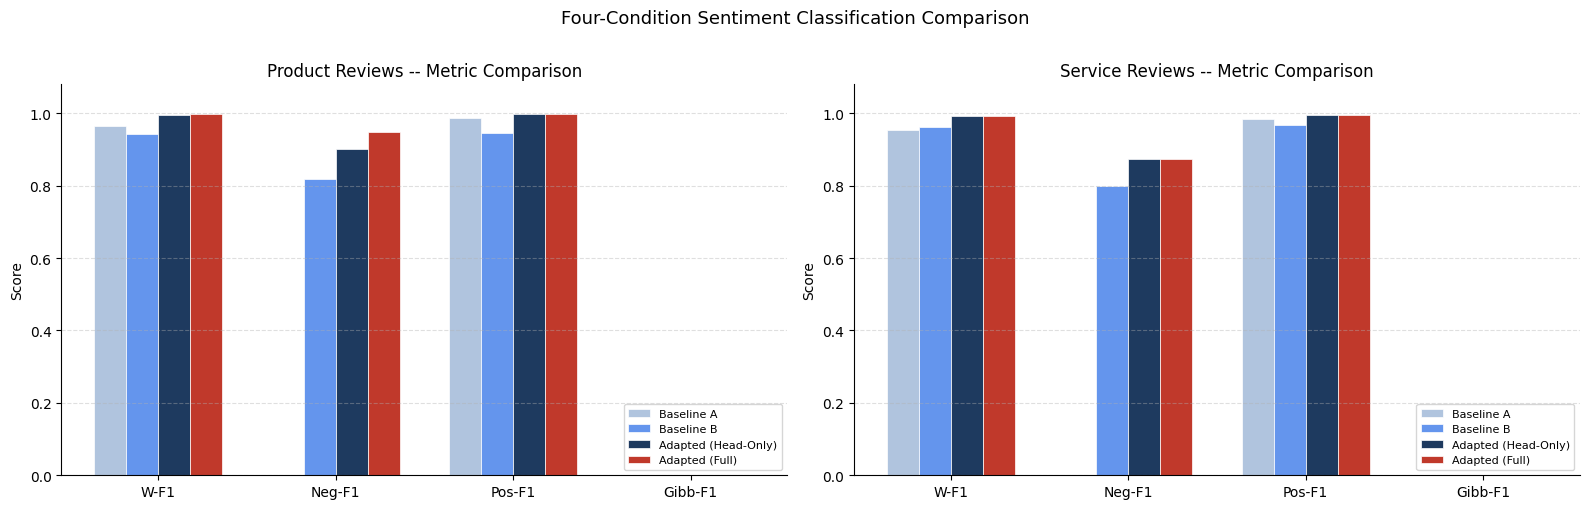

In [32]:
def plot_summary_bars_full(summary):
    '''
    Grouped bar chart comparing four conditions across four metrics for each dataset.

    Parameters
    ----------
    summary : pd.DataFrame  Output of build_summary_table_full().
    '''
    metrics  = ['W-F1', 'Neg-F1', 'Pos-F1']
    datasets = ['Product', 'Service']
    colors   = ['#b0c4de', '#6495ed', '#1e3a5f', '#c0392b']
    labels   = ['Baseline A', 'Baseline B', 'Adapted (Head-Only)', 'Adapted (Full)']

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

    for ax, ds in zip(axes, datasets):
        cols = [f'{ds} {m}' for m in metrics]
        vals = summary[cols].values          # shape (4, 4)

        x       = range(len(metrics))
        n_cond  = len(labels)
        width   = 0.18
        offsets = [(-1.5 + i) * width for i in range(n_cond)]

        for j, (offset, color, label) in enumerate(zip(offsets, colors, labels)):
            ax.bar([xi + offset for xi in x], vals[j], width,
                   label=label, color=color, edgecolor='white', linewidth=0.5)

        ax.set_title(f'{ds} Reviews -- Metric Comparison', fontsize=12)
        ax.set_xticks(list(x))
        ax.set_xticklabels(metrics)
        ax.set_ylim(0, 1.08)
        ax.set_ylabel('Score')
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

    # Single shared legend on the right subplot (upper right)
    handles, leg_labels = axes[-1].get_legend_handles_labels()
    axes[-1].legend(handles, leg_labels, fontsize=8, loc='upper right')

    plt.suptitle('Four-Condition Sentiment Classification Comparison', fontsize=13, y=1.01)
    plt.tight_layout()

    save_path = os.path.join(CACHE_DIR, 'summary_bar_chart_full.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Summary bar chart saved -> {save_path}')
    plt.show()


plot_summary_bars_full(summary_full)


---

## Section 14 — Full Fine-Tune: Misclassified Samples

All samples that the full fine-tuned model misclassified, sorted by prediction confidence (descending).
High-confidence errors are surfaced first as they are the most diagnostically useful.


In [ ]:
# -- Section 14: Full Fine-Tune -- All Misclassified Samples -----------------
print('Section 14 — Full Fine-Tune: Misclassified Samples')
print('=' * 55)

for ds_name, results, data_dict in [
    ('Product', full_product_results, product_data),
    ('Service', full_service_results, service_data),
]:
    rows = []
    for idx, (true, pred, probs, text) in enumerate(zip(
            results['all_labels'],
            results['all_preds'],
            results['all_probs'],
            data_dict['test']['text'].tolist())):
        if true != pred:
            rows.append({
                'index':      data_dict['test'].index[idx],
                'true_label': LABEL_MAP[true],
                'pred_label': LABEL_MAP[pred],
                'confidence': round(probs[pred], 4),
                'comment':    str(text)[:300],
            })

    df_mis = (pd.DataFrame(rows)
                .sort_values('confidence', ascending=False)
                .reset_index(drop=True))

    print(f'\n[{ds_name}] Full Fine-Tune — {len(df_mis)} misclassified samples')
    pd.set_option('display.max_colwidth', 100)
    pd.set_option('display.max_rows', None)
    display(df_mis)
    pd.reset_option('display.max_colwidth')
    pd.reset_option('display.max_rows')


---

## Section 15 — Prediction Distribution & Confidence Analysis

Two visualisations for the Full Fine-Tune condition:

1. **Ring (donut) charts** — predicted class distribution (Negative / Positive / Gibberish) for Product and Service reviews.
2. **Confidence curves** — for each predicted class, predictions are sorted by confidence (descending). The x-axis shows the cumulative percentage of that class's predictions; the y-axis shows the confidence value. Reveals how committed the model is to its predictions for each class.


Ring chart saved -> /home/levizenith/SednaAI/cache_hlc/full_finetune_donut.png


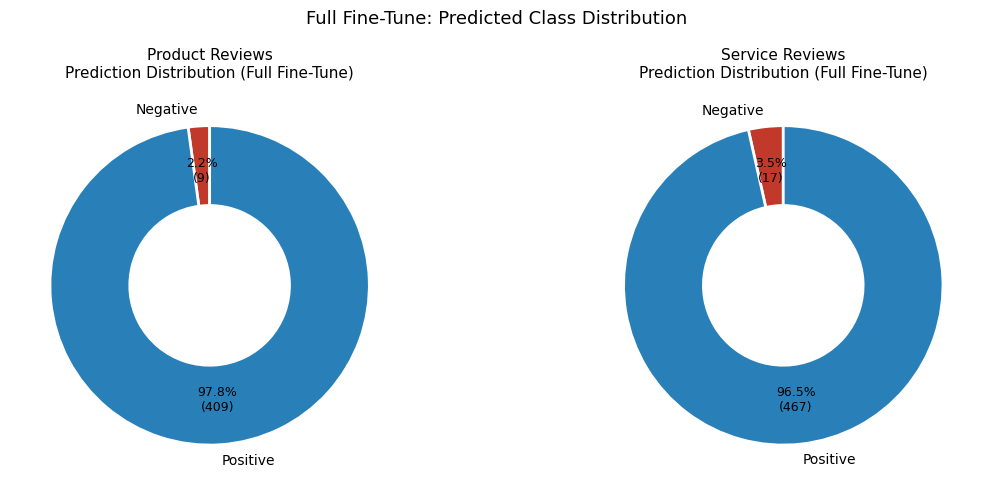

In [45]:
# -- Section 15a: Predicted Class Distribution (Ring / Donut Charts) ----------
from collections import Counter

_CLASS_NAMES = ['Negative', 'Positive', 'Gibberish']
_RING_COLORS = ['#c0392b', '#2980b9', '#95a5a6']

fig1, axes1 = plt.subplots(1, 2, figsize=(12, 5))

for ax, ds_name, results in [
    (axes1[0], 'Product', full_product_results),
    (axes1[1], 'Service', full_service_results),
]:
    _counts = Counter(results['all_preds'])
    _sizes  = [_counts.get(i, 0) for i in range(3)]
    _total  = sum(_sizes)

    # Filter out classes with zero predictions for a clean ring
    _nz = [(s, c, n) for s, c, n in zip(_sizes, _RING_COLORS, _CLASS_NAMES) if s > 0]
    _sz, _co, _nm = (list(z) for z in zip(*_nz)) if _nz else ([], [], [])

    wedges, texts, autotexts = ax.pie(
        _sz,
        labels=_nm,
        colors=_co,
        autopct=lambda p: f'{p:.1f}%\n({int(round(p * _total / 100))})',
        startangle=90,
        pctdistance=0.72,
        wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
    )
    for t in autotexts:
        t.set_fontsize(9)

    ax.set_title(f'{ds_name} Reviews\nPrediction Distribution (Full Fine-Tune)', fontsize=11)

plt.suptitle('Full Fine-Tune: Predicted Class Distribution', fontsize=13)
plt.tight_layout()

_save1 = os.path.join(CACHE_DIR, 'full_finetune_donut.png')
plt.savefig(_save1, dpi=150, bbox_inches='tight')
print(f'Ring chart saved -> {_save1}')
plt.show()


Confidence distribution chart saved -> /home/levizenith/SednaAI/cache_hlc/full_finetune_confidence_dist.png


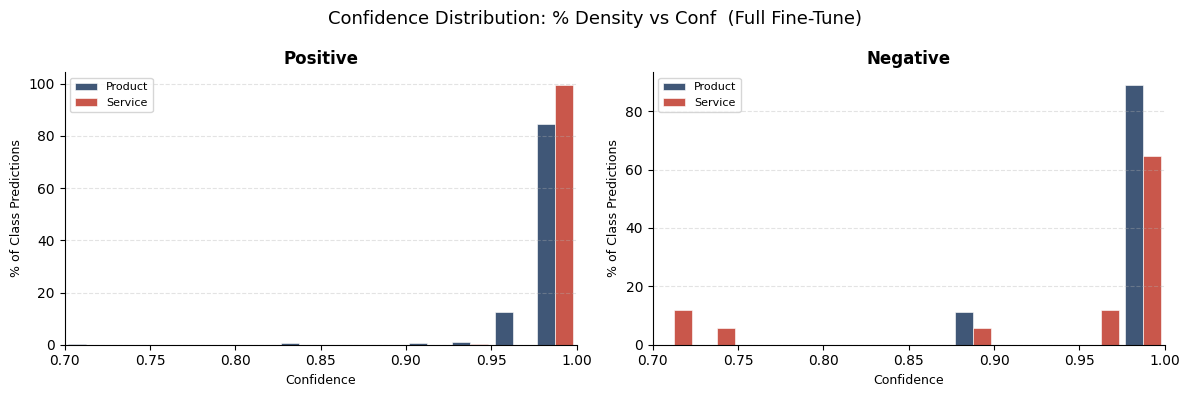

In [48]:
# -- Section 15b: Confidence Distribution (% Density vs Confidence) ---------

_CLASS_NAMES = ['Positive', 'Negative']
_CLASS_IDX   = [1, 0]
_DS_STYLES = [
    ('Product', full_product_results, '#1e3a5f'),
    ('Service', full_service_results, '#c0392b'),
]

_bins        = np.linspace(0.5, 1.0, 21)     # 20 bins from 0.5 to 1.0
_bin_centers = (_bins[:-1] + _bins[1:]) / 2
_bar_width   = (_bins[1] - _bins[0]) * 0.42  # side-by-side bars

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4))

for ax, cls_idx, cls_name in zip(axes2, _CLASS_IDX, _CLASS_NAMES):
    for offset, (ds_name, results, bar_color) in zip(
            [-_bar_width / 2, _bar_width / 2], _DS_STYLES):
        preds = results['all_preds']
        probs = results['all_probs']

        cls_confs = [
            probs[i][preds[i]]
            for i in range(len(preds)) if preds[i] == cls_idx
        ]

        if not cls_confs:
            continue

        counts, _ = np.histogram(cls_confs, bins=_bins)
        pct = counts / sum(counts) * 100

        ax.bar(_bin_centers + offset, pct, width=_bar_width,
               color=bar_color, label=ds_name, alpha=0.85, edgecolor='white', linewidth=0.5)

    ax.set_title(cls_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Confidence', fontsize=9)
    ax.set_ylabel('% of Class Predictions', fontsize=9)
    ax.set_xlim(0.7, 1.0)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.suptitle(
    'Confidence Distribution: % Density vs Conf  (Full Fine-Tune)',
    fontsize=13
)
plt.tight_layout()

_save2 = os.path.join(CACHE_DIR, 'full_finetune_confidence_dist.png')
plt.savefig(_save2, dpi=150, bbox_inches='tight')
print(f'Confidence distribution chart saved -> {_save2}')
plt.show()


---

## Section 16 — Misclassified Samples (All Conditions)

All misclassified samples from the frozen-backbone adapted models, sorted by
prediction confidence descending. High-confidence errors are the most informative
failure cases.


In [ ]:
# ── Section 16: All misclassified samples, confidence-sorted ─────────────────
import pandas as pd

_DISPLAY_COLS = ['index', 'true_label', 'pred_label', 'confidence', 'comment']

for _label, _mis in [('Product (Full Fine-Tune)', full_product_mis),
                      ('Service (Full Fine-Tune)', full_service_mis)]:
    _df = (_mis[_DISPLAY_COLS]
             .sort_values('confidence', ascending=False)
             .reset_index(drop=True))
    print(f'\n{"=" * 55}')
    print(f'{_label} — {len(_df)} misclassified samples')
    print(f'{"=" * 55}')
    pd.set_option('display.max_rows', None)
    pd.set_option('display.float_format', '{:.4f}'.format)
    display(_df)
    pd.reset_option('display.max_rows')
    pd.reset_option('display.float_format')


In [47]:
print('=' * 55)
print('All sections complete (including Full Fine-Tuning).')
print(f'Cached outputs -> {CACHE_DIR}')
print('  Sections 11-12 : Full fine-tuning training & evaluation')
print('  Section  13    : Four-condition bar chart comparison')
print('  Section  14    : Misclassified samples (Full Fine-Tune)')
print('  Section  15    : Ring charts + confidence curves')
print('=' * 55)


All sections complete (including Full Fine-Tuning).
Cached outputs -> /home/levizenith/SednaAI/cache_hlc
  Sections 11-12 : Full fine-tuning training & evaluation
  Section  13    : Four-condition bar chart comparison
  Section  14    : Misclassified samples (Full Fine-Tune)
  Section  15    : Ring charts + confidence curves


---

## Section 17 — HLC Review Analysis

### 17.1 Product Reviews — Browse by Type

No ML needed. Reviews are grouped by product type using regex matching on the `product_name` column.

- `list_product_types(csv_path)` — show all product type categories and review counts
- `browse_by_type(csv_path, product_type, n)` — display sample reviews for a given type

### 17.2 Service Reviews — BERTopic Analysis

Topic modelling pipeline: SBERT embeddings → UMAP → HDBSCAN → c-TF-IDF.

- `run_bertopic(csv_path, ...)` — embed, cluster and display discovered topics (cached)
- `check_topic_comments(topic)` — inspect all reviews assigned to a topic

In [55]:
# ── Section 17 imports ────────────────────────────────────────────────────────
import re, hashlib, pickle
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from tqdm.auto import tqdm
import umap
import hdbscan
from collections import Counter

In [56]:
# ── Section 17 shared state & helpers ────────────────────────────────────────
_bt_model      = None
_bt_docs       = None
_bt_topics     = None
_bt_orig_idx   = None
_bt_embeddings = None   # raw SBERT embeddings, populated by run_bertopic()
_bt_cache_key  = None   # embedding cache key (identifies the docs)
_bt_model_key  = None   # BERTopic model cache key (identifies model + hyperparams)
_product_csv   = None

# Sentiment adjectives and generic filler that drown out real topic signal
_DEFAULT_EXTRA_STOPS = [
    'lovely','great','good','nice','perfect','excellent','beautiful',
    'amazing','brilliant','wonderful','fantastic','gorgeous','superb',
    'awesome','happy','pleased','delighted',
    'thank','thanks','love','loved','like','liked',
    'product','item','buy','bought','purchase','ordered','order',
    'really','very','highly','absolutely','totally','definitely',
    'recommend','recommended','exactly','just','also','bit',
    'quality',
]

# Morandi palette — muted, desaturated, high readability
_MORANDI = [
    '#9aA8A0', '#C4A882', '#A89BAE', '#88A4B8', '#B8A09A',
    '#7A9E8E', '#C9B89A', '#8896B0', '#B0A0B8', '#A8B898',
    '#C8B0A0', '#90A8B8', '#B8C0A0', '#A89888', '#98A8C0',
    '#B0B8A8', '#C0A8B0', '#88B0A8', '#B8B0C0', '#A0B8A8',
]

# Product type rules — order matters (specific before generic)
_TYPE_RULES = [
    (r'Fitted\s+Sheet',                           'Fitted Sheet'),
    (r'Cot\s+Sheet',                              'Cot Sheet'),
    (r'Curtains?',                                'Curtains'),
    (r'Tiebacks?',                                'Tiebacks'),
    (r'Lampshade',                                'Lampshade'),
    (r'Pillowcases?(?:\s+\(Pair\))?',             'Pillowcase'),
    (r'Cushion',                                  'Cushion'),
    (r'Sleep\s+Bag',                              'Sleep Bag'),
    (r'Sleepsuit',                                'Sleepsuit'),
    (r'(?:Fleece\s+|Quilted\s+|Sherpa\s+)?Blanket',              'Blanket'),
    (r'(?:Fleece\s+|Quilted\s+|Velvet\s+|Sherpa\s+)?Throw',      'Throw'),
    (r'(?:Fleece\s+|Sherpa\s+|Patchwork\s+)?Bedding',            'Bedding'),
]

def _extract_product_type(product_name):
    for pattern, label in _TYPE_RULES:
        if re.search(pattern, str(product_name), re.IGNORECASE):
            return label
    return 'Other'

def _normalise_plurals(words):
    word_set = set(words)
    to_remove = set()
    for w in words:
        if w + 's' in word_set or w + 'es' in word_set:
            to_remove.add(w)
        if w.endswith('ies') and w[:-3] + 'y' in word_set:
            to_remove.add(w[:-3] + 'y')
    return [w for w in words if w not in to_remove]

def _dedup_keywords(phrases):
    cleaned = []
    for phrase in phrases:
        tokens = phrase.split()
        if len(tokens) == 2 and tokens[0] == tokens[1]:
            continue
        cleaned.append(phrase)
    all_words = []
    for phrase in cleaned:
        all_words.extend(phrase.split())
    all_words = list(dict.fromkeys(all_words))
    all_words = _normalise_plurals(all_words)
    normalised_set = set(all_words)
    seen_words = set()
    kept = []
    for phrase in sorted(cleaned, key=lambda p: len(p.split())):
        tokens = [t for t in phrase.split() if t in normalised_set]
        if not tokens:
            continue
        word_set = set(tokens)
        if word_set <= seen_words:
            continue
        kept.append(' '.join(tokens))
        seen_words |= word_set
    return kept

def _is_utf16(csv_path):
    with open(csv_path, 'rb') as f:
        bom = f.read(2)
    return bom in (b'\xff\xfe', b'\xfe\xff')

def _load_csv(csv_path):
    if _is_utf16(csv_path):
        df = pd.read_csv(csv_path, encoding='utf-16', sep='\t')
        df.columns = df.columns.str.strip()
        return df, 'service'
    for enc in ('utf-8-sig', 'utf-8', 'cp1252', 'latin-1'):
        try:
            return pd.read_csv(csv_path, encoding=enc), 'standard'
        except UnicodeDecodeError:
            continue
    raise RuntimeError(f'Cannot decode {csv_path}')

def _load_docs(csv_path, text_col, product_type_filter=None):
    df, kind = _load_csv(csv_path)
    if kind == 'service':
        df = df[df['Review Language'] == 'en'].copy()
        df['_text'] = (df['Review Title'].fillna('') + ' ' +
                       df['Review Content'].fillna('')).str.strip()
        text_col = '_text'
    mask = df[text_col].notna()
    if 'language' in df.columns:
        mask = mask & (df['language'] == 'en')
    if product_type_filter and 'product_name' in df.columns:
        mask = mask & (df['product_name'].apply(_extract_product_type) == product_type_filter)
    df_m = df[mask].copy()
    df_m[text_col] = df_m[text_col].astype(str).str.strip()
    df_m = df_m[df_m[text_col].str.len() > 10]
    return df_m[text_col].tolist(), df_m.index.tolist()

In [57]:
def list_product_types(csv_path, text_col='content'):
    '''Show all product type categories and their review counts.'''
    global _product_csv
    _product_csv = csv_path

    df, _ = _load_csv(csv_path)
    mask = df[text_col].notna()
    if 'language' in df.columns:
        mask = mask & (df['language'] == 'en')
    df_m = df[mask].copy()
    df_m[text_col] = df_m[text_col].astype(str).str.strip()
    df_m = df_m[df_m[text_col].str.len() > 10]
    df_m['_type'] = df_m['product_name'].apply(_extract_product_type)

    counts = df_m['_type'].value_counts().reset_index()
    counts.columns = ['Product Type', 'Review Count']
    display(counts)


def browse_by_type(csv_path, product_type=None, text_col='content', n=20):
    '''Display up to n reviews filtered by product type.'''
    global _product_csv
    _product_csv = csv_path

    df, _ = _load_csv(csv_path)
    mask = df[text_col].notna()
    if 'language' in df.columns:
        mask = mask & (df['language'] == 'en')
    df_m = df[mask].copy()
    df_m[text_col] = df_m[text_col].astype(str).str.strip()
    df_m = df_m[df_m[text_col].str.len() > 10]

    if product_type is not None and 'product_name' in df_m.columns:
        df_m['_type'] = df_m['product_name'].apply(_extract_product_type)
        df_m = df_m[df_m['_type'] == product_type]

    cols = [c for c in ['review_id', 'stars', 'product_name', text_col] if c in df_m.columns]
    result = df_m[cols].head(n).reset_index(drop=True)
    label = product_type if product_type else 'All Types'
    print(f'{label}: {len(df_m)} reviews total, showing {len(result)}')
    display(result)


def visualise_product_types(csv_path, text_col='content', top_n_words=5):
    '''
    Two-panel visualisation for product reviews:
      1. Horizontal bar chart — total review count per product type (all languages)
      2. Keyword table — top representative terms per type (English reviews only)
    '''
    global _product_csv
    _product_csv = csv_path

    df, _ = _load_csv(csv_path)

    # All reviews (all languages, no length filter) for bar chart counts
    df_all = df[df[text_col].notna()].copy()
    df_all['_type'] = df_all['product_name'].apply(_extract_product_type)
    type_counts = df_all['_type'].value_counts()

    # English reviews with length filter for keyword extraction only
    mask_en = df[text_col].notna()
    if 'language' in df.columns:
        mask_en = mask_en & (df['language'] == 'en')
    df_en = df[mask_en].copy()
    df_en[text_col] = df_en[text_col].astype(str).str.strip()
    df_en = df_en[df_en[text_col].str.len() > 10]
    df_en['_type'] = df_en['product_name'].apply(_extract_product_type)

    # ── Bar chart ─────────────────────────────────────────────────────────────
    n_types = len(type_counts)
    fig, ax = plt.subplots(figsize=(8, max(4, n_types * 0.52)))
    bars = ax.barh(
        type_counts.index[::-1], type_counts.values[::-1],
        color=[_MORANDI[i % len(_MORANDI)] for i in range(n_types)],
        edgecolor='none', height=0.6,
    )
    ax.bar_label(bars, padding=5, fontsize=10, color='#555555')
    ax.set_xlabel('Review Count', color='#666666')
    ax.set_title('Product Reviews by Type', fontsize=13, fontweight='bold', color='#444444', pad=12)
    ax.tick_params(colors='#666666')
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_color('#cccccc')
    ax.set_xlim(0, type_counts.max() * 1.18)
    ax.set_facecolor('#fafafa')
    fig.patch.set_facecolor('#fafafa')
    plt.tight_layout()
    plt.show()

    # ── Keyword table ─────────────────────────────────────────────────────────
    from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
    full_stops = list(ENGLISH_STOP_WORDS) + _DEFAULT_EXTRA_STOPS

    rows = []
    for ptype in type_counts.index:
        texts = df_en[df_en['_type'] == ptype][text_col].tolist()
        if not texts:
            rows.append({'Type': ptype, 'Top Keywords (EN)': '—', 'Total Count': int(type_counts[ptype])})
            continue
        vec = CountVectorizer(
            stop_words=full_stops, ngram_range=(1, 2),
            max_features=300, min_df=1,
        )
        try:
            X = vec.fit_transform(texts)
            totals = X.sum(axis=0).A1
            top_idx = totals.argsort()[::-1][:top_n_words * 3]
            candidates = vec.get_feature_names_out()[top_idx].tolist()
            keywords = ', '.join(_dedup_keywords(candidates)[:top_n_words])
        except Exception:
            keywords = '—'
        rows.append({'Type': ptype, 'Top Keywords (EN)': keywords, 'Total Count': int(type_counts[ptype])})

    display(pd.DataFrame(rows))

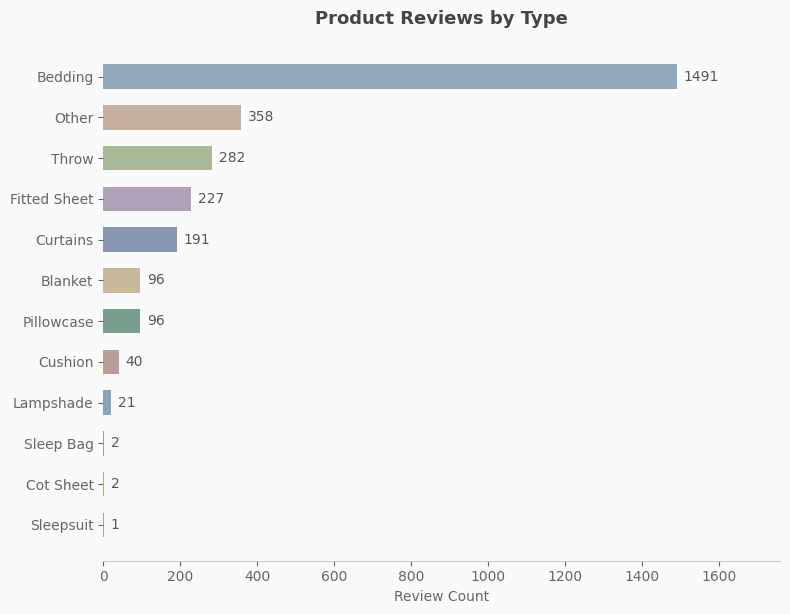

,Type,Top Keywords (EN),Total Count
0,Bedding,"bedding, loves, design, set, bed",1491
1,Other,"bag, room, little, loves, soft",358
2,Throw,"soft, throw, warm, cosy, design",282
3,Fitted Sheet,"sheet, set, bed, bedding, duvet",227
4,Curtains,"curtains, room, blackout, design, set",191
5,Blanket,"blanket, soft, loves, free, colours",96
6,Pillowcase,"design, pillow, bedding, match, delivery",96
7,Cushion,"cushions, covers, festive, look, addition",40
8,Lampshade,"shade, lampshade, lamp, easy, size",21
9,Sleep Bag,"value, sleep, money, designed, beautifully",2


In [58]:
# ── 17.1 Product Reviews ─────────────────────────────────────────────────────

# Bar chart + keyword table for all product types
visualise_product_types(PRODUCT_CSV)

# Browse raw reviews for a specific type
# browse_by_type(PRODUCT_CSV, 'Bedding', n=20)

# Inspect all reviews in a product type (same interface as service topics)
# check_topic_comments('Bedding')
# check_topic_comments('Curtains')

In [59]:
def check_topic_comments(topic):
    '''
    Display all reviews in a given topic.

    For service reviews (BERTopic): pass an int, e.g. check_topic_comments(0)
    For product reviews (by type):  pass a string, e.g. check_topic_comments("Bedding")
    '''
    if isinstance(topic, str):
        if _product_csv is None:
            print('Run list_product_types() or visualise_product_types() first.')
            return
        docs, orig_idx = _load_docs(_product_csv, 'content', product_type_filter=topic)
        if not docs:
            print(f'No reviews found for product type "{topic}".')
            return
        rows = [{'csv_index': orig_idx[i], 'comment': docs[i]} for i in range(len(docs))]
        label = f'Product type "{topic}"'
    else:
        if _bt_docs is None:
            print('Run run_bertopic() first.')
            return
        indices = [i for i, t in enumerate(_bt_topics) if t == topic]
        if not indices:
            print(f'Topic {topic} has no assigned reviews.')
            return
        rows = [{'csv_index': _bt_orig_idx[i], 'comment': _bt_docs[i]} for i in indices]
        label = f'Topic {topic}'

    df = pd.DataFrame(rows)
    print(f'{label}: {len(rows)} reviews')

    html = df.to_html(index=False, escape=False)
    scrollable = f'''
    <div style="height:400px; overflow-y:auto; border:1px solid #444; border-radius:4px;">
      <style>
        .scroll-tbl table {{ width:100%; border-collapse:collapse; font-size:13px; }}
        .scroll-tbl th {{ position:sticky; top:0; background:#2d2d2d; color:#ddd;
                          padding:8px 12px; text-align:left; z-index:1; }}
        .scroll-tbl td {{ padding:7px 12px; border-bottom:1px solid #333;
                          color:#ccc; vertical-align:top; word-break:break-word; }}
        .scroll-tbl td:first-child {{ width:80px; white-space:nowrap; color:#888; }}
        .scroll-tbl td:last-child  {{ width:auto; }}
        .scroll-tbl tr:hover td {{ background:#2a2a2a; }}
      </style>
      <div class="scroll-tbl">{html}</div>
    </div>
    '''
    from IPython.display import HTML
    display(HTML(scrollable))


def run_bertopic(
    csv_path,
    text_col          = 'content',
    n_neighbors       = 30,
    n_components      = 10,
    min_dist          = 0.1,
    metric            = 'cosine',
    min_cluster_size  = 60,
    min_samples       = 5,
    ngram_range       = (1, 2),
    min_df            = 2,
    max_df            = 0.95,
    top_n_words       = 4,
    extra_stops       = None,
    reduce_outliers   = True,
):
    '''
    Run BERTopic on a CSV and display discovered topics with visualisation.
    Results are cached in CACHE_DIR — repeated calls with identical inputs return instantly.

    Parameters
    ----------
    reduce_outliers : bool
        If True, reassign noise points to their nearest topic by embedding
        similarity after clustering. Reduces the unassigned count significantly.
    '''
    global _bt_model, _bt_docs, _bt_topics, _bt_orig_idx
    global _bt_embeddings, _bt_cache_key, _bt_model_key

    if extra_stops is None:
        stops = _DEFAULT_EXTRA_STOPS
    else:
        stops = list(set(_DEFAULT_EXTRA_STOPS + list(extra_stops)))

    # ── Raw total (no length filter, for display) ─────────────────────────────
    df_raw, kind = _load_csv(csv_path)
    if kind == 'service':
        df_raw = df_raw[df_raw['Review Language'] == 'en']
        total_raw = df_raw[df_raw['Review Content'].notna()].shape[0]
    else:
        mask_raw = df_raw[text_col].notna()
        if 'language' in df_raw.columns:
            mask_raw = mask_raw & (df_raw['language'] == 'en')
        total_raw = int(mask_raw.sum())

    docs, orig_idx = _load_docs(csv_path, text_col)
    print(f'{total_raw} reviews total  |  {len(docs)} used for BERTopic (len > 10)')

    # ── Cache paths ───────────────────────────────────────────────────────────
    mtime     = str(os.path.getmtime(csv_path))
    emb_raw   = f'{csv_path}|{mtime}|{text_col}'
    emb_key   = hashlib.md5(emb_raw.encode()).hexdigest()[:12]
    stops_key = '|'.join(sorted(stops))
    model_raw = (f'{emb_key}|{n_neighbors}|{n_components}|{min_dist}|{metric}|'
                 f'{min_cluster_size}|{min_samples}|{ngram_range}|'
                 f'{min_df}|{max_df}|{top_n_words}|{stops_key}')
    model_key = hashlib.md5(model_raw.encode()).hexdigest()[:12]
    emb_path   = os.path.join(CACHE_DIR, f'bt_emb_{emb_key}.pkl')
    model_path = os.path.join(CACHE_DIR, f'bt_model_{model_key}.pkl')

    # ── Embeddings (cached) ───────────────────────────────────────────────────
    if os.path.exists(emb_path):
        print(f'[Cache] Embeddings  <- {emb_path}')
        with open(emb_path, 'rb') as fh:
            c = pickle.load(fh)
        docs, orig_idx, embeddings = c['docs'], c['orig_idx'], c['embeddings']
    else:
        print('Embedding with all-mpnet-base-v2 ...')
        embedder   = SentenceTransformer('all-mpnet-base-v2')
        embeddings = embedder.encode(
            docs, batch_size=64, show_progress_bar=True,
            convert_to_numpy=True, normalize_embeddings=True,
        )
        del embedder
        with open(emb_path, 'wb') as fh:
            pickle.dump({'docs': docs, 'orig_idx': orig_idx, 'embeddings': embeddings}, fh)
        print(f'[Cache] Embeddings  -> {emb_path}')

    # ── BERTopic model (cached) ───────────────────────────────────────────────
    if os.path.exists(model_path):
        print(f'[Cache] Model       <- {model_path}')
        with open(model_path, 'rb') as fh:
            c = pickle.load(fh)
        topic_model, topics = c['model'], c['topics']
    else:
        print('Fitting BERTopic ...')
        from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
        full_stops = list(ENGLISH_STOP_WORDS) + stops

        umap_model = umap.UMAP(
            n_neighbors=n_neighbors, n_components=n_components,
            min_dist=min_dist, metric=metric, random_state=SEED,
        )
        hdbscan_model = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size, min_samples=min_samples,
            metric='euclidean', cluster_selection_method='eom',
            prediction_data=True,
        )
        vectorizer_model = CountVectorizer(
            stop_words=full_stops, ngram_range=ngram_range,
            min_df=min_df, max_df=max_df,
        )
        topic_model = BERTopic(
            embedding_model=None, umap_model=umap_model,
            hdbscan_model=hdbscan_model, vectorizer_model=vectorizer_model,
            top_n_words=top_n_words, calculate_probabilities=False, verbose=False,
        )
        with tqdm(total=1, desc='BERTopic fit_transform') as pbar:
            topics, _ = topic_model.fit_transform(docs, embeddings=embeddings)
            pbar.update(1)
        with open(model_path, 'wb') as fh:
            pickle.dump({'model': topic_model, 'topics': topics}, fh)
        print(f'[Cache] Model       -> {model_path}')

    # ── Reduce outliers (post-processing, not cached) ─────────────────────────
    noise_before = sum(1 for t in topics if t == -1)
    if reduce_outliers and noise_before > 0:
        print(f'Reducing outliers ({noise_before} noise points) ...')
        topics = topic_model.reduce_outliers(
            docs, topics,
            strategy='embeddings',
            embeddings=embeddings,
        )
        noise_after = sum(1 for t in topics if t == -1)
        print(f'Noise: {noise_before} -> {noise_after}  ({noise_before - noise_after} reassigned)')

    # ── Store globally ────────────────────────────────────────────────────────
    _bt_model      = topic_model
    _bt_docs       = docs
    _bt_topics     = topics
    _bt_orig_idx   = orig_idx
    _bt_embeddings = embeddings
    _bt_cache_key  = emb_key
    _bt_model_key  = model_key

    # ── Build result rows with deduped keyword names ──────────────────────────
    topic_counts = Counter(t for t in topics if t != -1)
    rows = []
    for tid, cnt in sorted(topic_counts.items(), key=lambda x: (-x[1], x[0])):
        raw_words = [w for w, _ in (topic_model.get_topic(tid) or [])]
        deduped   = _dedup_keywords(raw_words)[:top_n_words]
        name      = ', '.join(deduped)
        rows.append({'Topic': tid, 'Name': name, 'Count': cnt})
    noise      = sum(1 for t in topics if t == -1)
    short_skip = total_raw - len(docs)
    rows.append({'Topic': -1, 'Name': f'noise / unassigned  (+{short_skip} too short)', 'Count': noise + short_skip})

    result_df = pd.DataFrame(rows)
    display(result_df)
    print(f'Topics: {len(topic_counts)}  |  Unassigned: {noise + short_skip}/{total_raw} ({(noise + short_skip)/total_raw*100:.1f}%)')

    # ── Visualisation ─────────────────────────────────────────────────────────
    plot_rows = [r for r in rows if r['Topic'] != -1]
    labels = [r['Name'] for r in plot_rows]
    counts = [r['Count'] for r in plot_rows]

    fig, ax = plt.subplots(figsize=(10, max(4, len(plot_rows) * 0.52)))
    bars = ax.barh(
        range(len(plot_rows)), counts,
        color=[_MORANDI[i % len(_MORANDI)] for i in range(len(plot_rows))],
        edgecolor='none', height=0.6,
    )
    ax.set_yticks(range(len(plot_rows)))
    ax.set_yticklabels(labels, fontsize=9, color='#444444')
    ax.bar_label(bars, padding=5, fontsize=9, color='#555555')
    ax.set_xlabel('Review Count', color='#666666')
    ax.set_title('Service Review Topic Clusters', fontsize=13, fontweight='bold', color='#444444', pad=12)
    ax.tick_params(colors='#666666')
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_color('#cccccc')
    ax.set_xlim(0, max(counts) * 1.18)
    ax.invert_yaxis()
    ax.set_facecolor('#fafafa')
    fig.patch.set_facecolor('#fafafa')
    plt.tight_layout()
    plt.show()

    return result_df

3238 reviews total  |  3238 used for BERTopic (len > 10)
[Cache] Embeddings  <- /home/levizenith/SednaAI/cache_hlc/bt_emb_fd9c4b31cb72.pkl
[Cache] Model       <- /home/levizenith/SednaAI/cache_hlc/bt_model_ccca1fe51fc5.pkl
Reducing outliers (780 noise points) ...
Noise: 780 -> 0  (780 reassigned)


,Topic,Name,Count
0,0,"efficient, customer service, quick service",1100
1,1,"bedding, christmas",720
2,2,"duvet, cover, duvet set",366
3,3,"dark, bedding, glow, dinosaur bedding",280
4,4,"blanket, fleece, throws",241
5,5,"linen, bed, linen company",198
6,6,"curtains, bedding",173
7,7,"granddaughter, grandsons, grandchildren, littl...",160
8,-1,noise / unassigned (+0 too short),0


Topics: 8  |  Unassigned: 0/3238 (0.0%)


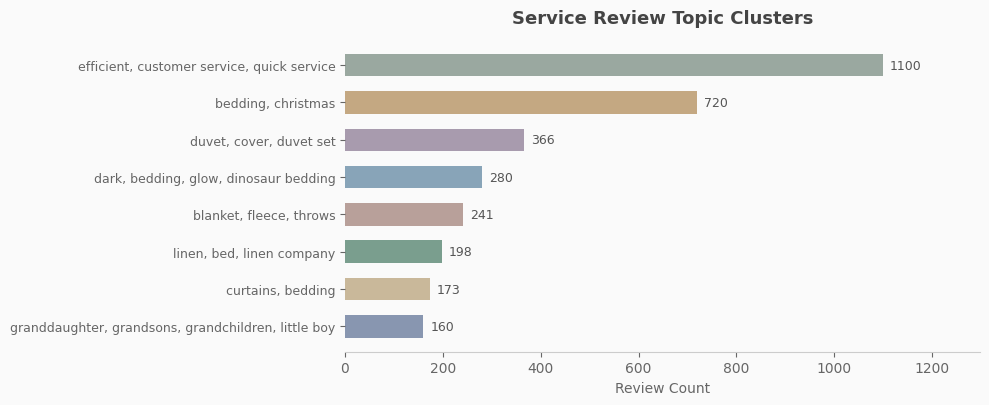

,Topic,Name,Count
0,0,"efficient, customer service, quick service",1100
1,1,"bedding, christmas",720
2,2,"duvet, cover, duvet set",366
3,3,"dark, bedding, glow, dinosaur bedding",280
4,4,"blanket, fleece, throws",241
5,5,"linen, bed, linen company",198
6,6,"curtains, bedding",173
7,7,"granddaughter, grandsons, grandchildren, littl...",160
8,-1,noise / unassigned (+0 too short),0


In [60]:
# ── 17.2 Service Reviews: usage ──────────────────────────────────────────────

# Run BERTopic on service reviews (first run embeds + fits, subsequent loads from cache)
run_bertopic(SERVICE_CSV)

# Inspect all reviews in a specific topic
# check_topic_comments(0)
# check_topic_comments(1)

In [61]:
# 查看 noise（-1）里的评论内容
check_topic_comments(-1)

Topic -1 has no assigned reviews.


In [62]:
# ── Product: top 3 types by review count ─────────────────────────────────────
# Bedding (most reviews), Other, Throw

print('=' * 60)
print('Product Type: Bedding')
print('=' * 60)
check_topic_comments('Bedding')

print('=' * 60)
print('Product Type: Other')
print('=' * 60)
check_topic_comments('Other')

print('=' * 60)
print('Product Type: Throw')
print('=' * 60)
check_topic_comments('Throw')

Product Type: Bedding
Product type "Bedding": 1451 reviews


csv_index,comment
0,Bought this duvet cover for my daughters Christmas. It looks lovely through the wrapper. Beautifull colour just like the photo on the website. I am sure she will love it. Arrived in time and well packaged. First time using this company will certainly use again.
1,Bought this duvet cover for my spare room. I just love it. Just like the photo on the website. Beautifull colour. Material is quite thick as well. It recommended ?€?wash before use?€? which I have done. It has dried lovely and soft. No fading on the colour either. Will certainly use this company again arrived on time and well packaged. They even leave a small piece of the packaging open so you can feel the material before you open it. My daughter is coming home for Christmas. She certainly won?€?t be cold in bed this visit! She will have a nice surprise on Christmas morning as I have bought her a new Christmas red patch duvet from this same company.
2,Lovely and warm. Nice change from cold cotton!
3,Grandson loved it
4,Bought at a good price. Arrived promptly and exactly as shown on website.
8,Lovely quality and looks really good
9,Super cool! ..... only wish it was %100 cotton.
11,Beautiful and soft. You will not regret it.
14,"Very happy with the bedding, it's washed lovely, nice and soft."
15,"Wonerful, as always. Would always recommend to a friend."


Product Type: Other
Product type "Other": 334 reviews


csv_index,comment
53,Looks amazing
340,Lovely fun design!
403,"Just received my new hoodie, it is sooo cool and cosy. I love it and won?€?t take it off again,\nCheers Petra"
452,Beautiful and my granddaughter happily agrees 5*
527,Lovely when up and good quality .
529,Great to make a feature wall for your little ones
533,"Lovely items thank you, they looks brilliant."
558,Made of actual fabric too!
561,"Good quality and size, easy to use, fun and bright."
657,Nice quality


Product Type: Throw
Product type "Throw": 276 reviews


csv_index,comment
5,"Super soft, super cute and a really great price!"
6,Amazing festive design with quality materials.
7,This is lovely and so many people commented how nice it looks ????
12,Fleecy and warm. Just how it looks in the picture. Definitely recommend
28,Beautiful bedding at great prices ????????????????
38,"Fab, bargain, definitely recommend"
67,Great value for money.
74,I was impressed with the quality of the product delivery and price
91,"Great quality, beautiful throw, great to cover king size bed????"
95,Love my new throw


In [63]:
# ── Service: top 3 topics by review count ────────────────────────────────────
# Topic 0 (customer service / delivery), Topic 1 (bedding / christmas), Topic 2 (duvet)

print('=' * 60)
print('Service Topic 0: efficient, customer service, quick service')
print('=' * 60)
check_topic_comments(0)

print('=' * 60)
print('Service Topic 1: bedding, christmas')
print('=' * 60)
check_topic_comments(1)

print('=' * 60)
print('Service Topic 2: duvet, cover, duvet set')
print('=' * 60)
check_topic_comments(2)

Service Topic 0: efficient, customer service, quick service
Topic 0: 1100 reviews


csv_index,comment
3,"Same quality Same quality, but there were no eyelets for the buttons."
4,"items that i ordered are fab quality,my… items that i ordered are fab quality,my order was prompt,i will be ordering again"
10,Quality is very good. Quality is very good. Kept me informed about delivery
12,Really good experience all round from first browsing to receipt of products… Really well presented online followed by great service and end product. Also very quick to resolve positively issues of concern to my full satisfaction.
16,"Customer service Customer service, speedy delivery, nice items."
20,"Quick and easy to deal with and… Quick and easy to deal with and delivered quick too , great company"
27,"Wonderful products Wonderful products, excellent value for money and quick delivery."
30,"Lovely Very nice, good price and fast delivery"
34,Beautiful and colourful Beautiful and colourful. Good quality. Quick service.
35,"Amazing products Great designs, well made items. Fantastic customer service"


Service Topic 1: bedding, christmas
Topic 1: 720 reviews


csv_index,comment
5,"I ordered a sleeping bag. I ordered a sleeping bag. The material although feeling soft to the hand felt somewhat rough on the cheek. If you want a refund you have to email Lucy. There is no return label so returning is not free. I received an email back from Lucy telling me to be aware as follows. I have copied and pasted this:- ‘’Please be aware the product must still be in its original, undamaged packaging & in a reselleable condition. If it's not returned in this condition we are unable to apply a refund’’ They do not seem to be interested in putting anything right. Most companies want to know about how their products are being received. I damaged the package slightly when it was opened. Of course packing gets a bit damaged when it’s opened. I have not returned it . Didn’t want to take the chance paying for postage and not get a refund. I feel that my consumer rights have been violated before even start a return. In this day and age of online shopping this is very customer unfriendly, judging by the tone of the email I received. Buyer beware!"
8,Excellent choice of children's bedding I was told when the goods were despatched and when the goods would be arriving
11,Love your bedding & little extras Love your bedding & little extra touches Thankyou
17,"Vibrant colours The bedding has arrived really quickly, the colours are vibrant and there were some nice added extras like a teddy blanket and storage bag which was a lovely surprise. I will definitely be buying again"
21,plenty of choice in designs plenty of choice in designs for bedding and sleepover sleeping bags (a bit too girly for me tbh - but sure to be appreciated by the granddaughter). Swift delivery.
22,Great quality Lovely soft bedding
23,"Gorgeous bedding set bought for my… Gorgeous bedding set bought for my niece's birthday, think she will love it"
28,"Lovely Products, Efficient Delivery Prompt, no charge delivery (always a plus with me). The woodland animals duvet cover, bunting and lampshade were beautiful for my granddaughters room for when staying at her Gramma's. Even came with a matching fabric bag that she loved carrying a few toys around in. Highly recommend the Company :-)"
31,"Lovely products Lovely products - sleeping bags. Was very pleased, the colours were vibrant and well made. 😍🫶 Everything was packaged well. Customer service has been so helpful and kind."
32,"Lovely soft bedding for toddlers Lovely soft bedding for toddlers, fab bright colours. Very sweet little teddy blanket included! Bought off Amazon."


Service Topic 2: duvet, cover, duvet set
Topic 2: 366 reviews


csv_index,comment
9,"Great products which solved our problem! My 2.5 year old was waking up saying she was cold and not interested in putting her duvet back on herself (!) I saw the sleeping bag and thought I would give it a try. Beautiful design, soft and cosy and it has worked a dream. So much so that I have ordered two and one for my son for when we go away. Quick delivery too. Great products, will definitely be back!"
13,You sent me a toddler duvet You sent me a toddler duvet
14,Would recommend Lovely duvet set which included a small blanket for teddies which my child loved. Would use again.
24,"Lovely digger themed duvet set Got some lovely digger themed sheets for our little boy, he loves the pattern and they seem good quality so far. Dispatched quickly too."
26,"Lucky find! My order was processed really fast by an efficient team. This company works with Royal Mail (and the client facing driver who covers my area has been an absolute life saver since 2021!). Great quality products: the glow-in-the-dark space themed double duvet cover washed well and glowed after lights off; and the alphabet and dinosaur double duvet covers washed well, and I haven’t spotted any mistakes in the spelling or flaws in the prints. Most importantly: the 4 year old recipient loves all 3!"
42,"Quick reliable delivery Quick reliable delivery, nice duvet set perfect for children"
58,Lovely design for winter Very pleased with attractive cosy duvet cover and pillow cases. Easy to order and prompt delivery. Thank you.
65,"Great duvet cover and pillow cases Speedy delivery, lovely product, sensible price. What more can you want!"
83,Duvet cover My order was delivered quickly and on time. It’s really great quality and comfortable
97,"Great price & quality Great price, quality of duvet & service!"


---

## Section 18 — LDA Baseline

Train a Latent Dirichlet Allocation model on the same service review corpus used for BERTopic,
with identical stop-word filtering and `K` set to match the number of BERTopic topics.

Results are cached — repeated runs load from disk instantly.

[Cache] LDA <- /home/levizenith/SednaAI/cache_hlc/lda_4e02cbc4dca3.pkl


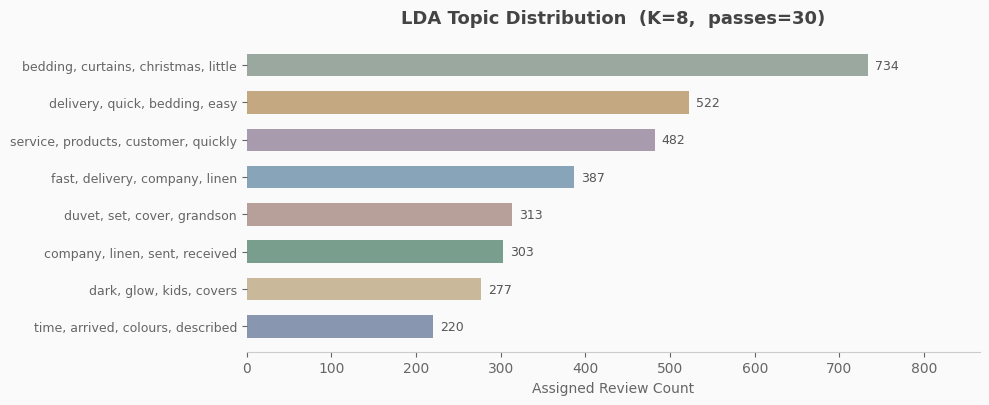

LDA topics: 8  |  Docs: 3238


In [64]:
# ── Section 18: LDA Baseline ─────────────────────────────────────────────────
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer as _CV, ENGLISH_STOP_WORDS

assert _bt_docs       is not None, 'Run run_bertopic(SERVICE_CSV) first (cell 60)'
assert _bt_cache_key  is not None, 'Re-run cell 60 to populate cache keys'

# ── Hyperparams ───────────────────────────────────────────────────────────────
LDA_K      = len(set(t for t in _bt_topics if t != -1))  # match BERTopic topic count
LDA_PASSES = 30
LDA_TOPK   = 10

# ── Cache key (keyed on docs identity + all hyperparams) ─────────────────────
_lda_stop_set  = sorted(set(list(ENGLISH_STOP_WORDS) + _DEFAULT_EXTRA_STOPS))
_lda_stops_key = '|'.join(_lda_stop_set)
_lda_raw_key   = f'{_bt_cache_key}|{LDA_K}|{LDA_PASSES}|{LDA_TOPK}|{_lda_stops_key}'
_lda_cache_key = hashlib.md5(_lda_raw_key.encode()).hexdigest()[:12]
_lda_cache_path = os.path.join(CACHE_DIR, f'lda_{_lda_cache_key}.pkl')

if os.path.exists(_lda_cache_path):
    print(f'[Cache] LDA <- {_lda_cache_path}')
    with open(_lda_cache_path, 'rb') as fh:
        _lda_c = pickle.load(fh)
    lda_model  = _lda_c['model']
    lda_vecs   = _lda_c['doc_topic']   # shape (n_docs, K)
    lda_words  = _lda_c['topic_words'] # list[list[str]]
    X_lda      = _lda_c['X']
else:
    # Vectorize (unigrams only — LDA works on individual tokens)
    print(f'Vectorizing {len(_bt_docs)} docs ...')
    _vectorizer = _CV(
        stop_words=_lda_stop_set,
        ngram_range=(1, 1),
        min_df=2, max_df=0.95,
        token_pattern=r'(?u)\b[a-zA-Z]{3,}\b',
    )
    X_lda   = _vectorizer.fit_transform(_bt_docs)
    _vocab  = _vectorizer.get_feature_names_out()
    print(f'Vocabulary size: {len(_vocab)}  |  Doc-term matrix: {X_lda.shape}')

    # Train LDA — use partial_fit loop so tqdm can show per-pass progress
    lda_model = LatentDirichletAllocation(
        n_components=LDA_K,
        max_iter=1,
        learning_method='online',
        batch_size=256,
        random_state=SEED,
    )
    for _ in tqdm(range(LDA_PASSES), desc=f'LDA training  K={LDA_K}'):
        lda_model.partial_fit(X_lda)

    # Document-topic distributions
    print('Computing document-topic distributions ...')
    lda_vecs = lda_model.transform(X_lda)   # (n_docs, K)

    # Top-K words per topic (sorted by component weight, descending)
    lda_words = []
    for comp in lda_model.components_:
        top_idx = comp.argsort()[-LDA_TOPK:][::-1]
        lda_words.append([_vocab[i] for i in top_idx])

    with open(_lda_cache_path, 'wb') as fh:
        pickle.dump({
            'model': lda_model, 'doc_topic': lda_vecs,
            'topic_words': lda_words, 'X': X_lda,
        }, fh)
    print(f'[Cache] LDA -> {_lda_cache_path}')

# ── Assign each doc to its highest-probability topic ─────────────────────────
_lda_assigned = np.argmax(lda_vecs, axis=1)
_lda_counts   = np.bincount(_lda_assigned, minlength=LDA_K)
_lda_order    = np.argsort(-_lda_counts)
_lda_labels   = [', '.join(lda_words[i][:4]) for i in _lda_order]

# ── Visualise topic distribution (same style as BERTopic) ────────────────────
fig, ax = plt.subplots(figsize=(10, max(4, LDA_K * 0.52)))
bars = ax.barh(
    range(LDA_K), _lda_counts[_lda_order],
    color=[_MORANDI[i % len(_MORANDI)] for i in range(LDA_K)],
    edgecolor='none', height=0.6,
)
ax.set_yticks(range(LDA_K))
ax.set_yticklabels(_lda_labels, fontsize=9, color='#444444')
ax.bar_label(bars, padding=5, fontsize=9, color='#555555')
ax.set_xlabel('Assigned Review Count', color='#666666')
ax.set_title(f'LDA Topic Distribution  (K={LDA_K},  passes={LDA_PASSES})',
             fontsize=13, fontweight='bold', color='#444444', pad=12)
ax.tick_params(colors='#666666')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.set_xlim(0, _lda_counts.max() * 1.18)
ax.invert_yaxis()
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('#fafafa')
plt.tight_layout()
plt.show()

print(f'LDA topics: {LDA_K}  |  Docs: {len(_bt_docs)}')

In [65]:
# ── LDA: top 2 topics by review count ────────────────────────────────────────
from IPython.display import HTML as _HTML, display as _disp

def _show_lda_topic(topic_id):
    '''Display reviews assigned to an LDA topic (same scrollable style as check_topic_comments).'''
    idxs = [i for i, t in enumerate(_lda_assigned) if t == topic_id]
    rows = [{'csv_index': _bt_orig_idx[i], 'comment': _bt_docs[i]} for i in idxs]
    df   = pd.DataFrame(rows)
    html = df.to_html(index=False, escape=False)
    scrollable = f'''
    <div style="height:400px; overflow-y:auto; border:1px solid #444; border-radius:4px;">
      <style>
        .scroll-tbl table {{ width:100%; border-collapse:collapse; font-size:13px; }}
        .scroll-tbl th {{ position:sticky; top:0; background:#2d2d2d; color:#ddd;
                          padding:8px 12px; text-align:left; z-index:1; }}
        .scroll-tbl td {{ padding:7px 12px; border-bottom:1px solid #333;
                          color:#ccc; vertical-align:top; word-break:break-word; }}
        .scroll-tbl td:first-child {{ width:80px; white-space:nowrap; color:#888; }}
        .scroll-tbl td:last-child  {{ width:auto; }}
        .scroll-tbl tr:hover td {{ background:#2a2a2a; }}
      </style>
      <div class="scroll-tbl">{html}</div>
    </div>
    '''
    _disp(_HTML(scrollable))

for _tid in _lda_order[:2]:
    _kw    = ', '.join(lda_words[_tid][:4])
    _count = int(_lda_counts[_tid])
    print('=' * 60)
    print(f'LDA Topic {_tid}  ({_count} reviews): {_kw}')
    print('=' * 60)
    _show_lda_topic(_tid)
    print()

LDA Topic 6  (734 reviews): bedding, curtains, christmas, little


csv_index,comment
0,Lovely products to match my bedding Lovely products to match my bedding. I bought bunting and wall stickers Speedy delivery thank you
1,Beautiful curtains and bedding with a… Beautiful curtains and bedding with a fantastic farm design. The wall stickers look great up as well. My son loves it!
2,"dinky dinosaur set dinky dinosaur set , fantastic bedding and curtains , toddler is very obsessed and happy Very happy with the free cushion covers i received would have liked if we got to choose or even got the given the same cushion covers as the set i ordered instead of completely different. It’s okay still very happy"
7,Great items Great items - just as described . My granddaughter loves the bunting and unicorn stickers.
11,Love your bedding & little extras Love your bedding & little extra touches Thankyou
13,You sent me a toddler duvet You sent me a toddler duvet
18,Excellent customer service and quality… Excellent customer service and quality products. My son was so excited for his new room and the amazing glow in the dark space decor all purchased from you. Thank you so much.
22,Great quality Lovely soft bedding
23,"Gorgeous bedding set bought for my… Gorgeous bedding set bought for my niece's birthday, think she will love it"
29,"Lovely curtains for granddaughters room. My curtains arrived well packed and in good time. They are really nice quality and look lovely hanging in my granddaughters room. The lining is separate and not the horrible sprayed on blackout, which goes brown. Easy to put up, lovely."



LDA Topic 0  (522 reviews): delivery, quick, bedding, easy


csv_index,comment
15,Very pleased with quick delivery and… Very pleased with quick delivery and the quality of the unicorn castle bedding and curtains
20,"Quick and easy to deal with and… Quick and easy to deal with and delivered quick too , great company"
25,"Very happy kiddo! Very quick delivery, super quality. Highly recommend!"
27,"Wonderful products Wonderful products, excellent value for money and quick delivery."
34,Beautiful and colourful Beautiful and colourful. Good quality. Quick service.
36,"Prompt delivery Prompt delivery, good prices, delightful products"
37,Product really good quality Product really good quality
41,Excellent quality Excellent quality. Speedy delivery.
42,"Quick reliable delivery Quick reliable delivery, nice duvet set perfect for children"
43,Gorgeous range and speedy shipping! Gorgeous range and very happy with the product. Our little guy is also pleased 💜 Thank you for the speedy shipping and great service.


---

## Section 19 — Evaluation: BERTopic vs LDA

Compare BERTopic and LDA on **Topic Diversity**: the proportion of unique words
across all topic top-10 word lists — higher means less redundancy between topics.

Results are cached — repeated runs load from disk instantly.

[Cache] Eval <- /home/levizenith/SednaAI/cache_hlc/eval_305937b63020.pkl

── Evaluation Summary ──────────────────────────


,Metric,BERTopic,LDA
0,Topic Diversity ↑,0.8947,0.8000


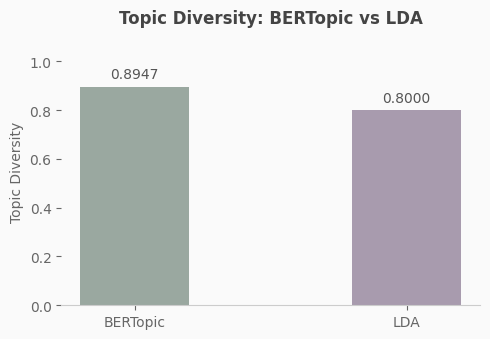

In [66]:
# ── Section 19: Evaluation — Topic Diversity ─────────────────────────────────

assert 'lda_words' in globals(), 'Run Section 18 (LDA training cell) first'
assert _bt_model   is not None,  'Re-run cell 60 (run_bertopic) first'

# ── Cache key (v3: diversity-only) ───────────────────────────────────────────
_eval_raw_key    = f'{_bt_model_key}|{_lda_cache_key}|v3'
_eval_cache_key  = hashlib.md5(_eval_raw_key.encode()).hexdigest()[:12]
_eval_cache_path = os.path.join(CACHE_DIR, f'eval_{_eval_cache_key}.pkl')

if os.path.exists(_eval_cache_path):
    print(f'[Cache] Eval <- {_eval_cache_path}')
    with open(_eval_cache_path, 'rb') as fh:
        _ev = pickle.load(fh)
    div_bt  = _ev['div_bt']
    div_lda = _ev['div_lda']
else:
    # Topic Diversity — unique top-10 words / total top-10 words
    # BERTopic: filter bigrams so comparison against LDA unigrams is fair
    def _diversity(word_lists, topk=10):
        all_w = [w for words in word_lists for w in words[:topk]]
        return round(len(set(all_w)) / len(all_w), 4) if all_w else 0.0

    _bt_topic_ids = sorted(set(t for t in _bt_topics if t != -1))
    _bt_words_uni = [
        [w for w, _ in (_bt_model.get_topic(tid) or []) if ' ' not in w][:10]
        for tid in _bt_topic_ids
    ]
    div_bt  = _diversity(_bt_words_uni)
    div_lda = _diversity(lda_words)

    with open(_eval_cache_path, 'wb') as fh:
        pickle.dump({'div_bt': div_bt, 'div_lda': div_lda}, fh)
    print(f'[Cache] Eval -> {_eval_cache_path}')

# ── Summary table ─────────────────────────────────────────────────────────────
_summary = pd.DataFrame({
    'Metric':   ['Topic Diversity ↑'],
    'BERTopic': [f'{div_bt:.4f}'],
    'LDA':      [f'{div_lda:.4f}'],
})
print('\n── Evaluation Summary ──────────────────────────')
display(_summary)

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(
    ['BERTopic', 'LDA'], [div_bt, div_lda],
    color=[_MORANDI[0], _MORANDI[2]],
    edgecolor='none', width=0.4,
)
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=10, color='#555')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Topic Diversity', color='#666')
ax.set_title('Topic Diversity: BERTopic vs LDA',
             fontsize=12, fontweight='bold', color='#444', pad=10)
ax.tick_params(colors='#666')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('#fafafa')
plt.tight_layout()
plt.show()

---

## Section 20 — Export Topic CSVs

Save each product type and each BERTopic service topic as an independent CSV
for downstream summarisation.

**Output structure:**
```
hlc_topic_csvs/
    product_topics/   ← one CSV per product type  (Bedding.csv, Curtains.csv …)
    service_topics/   ← one CSV per BERTopic topic (topic_0.csv, topic_1.csv …)
```

Each CSV includes a `sentiment` column derived from the star rating:
`1–2 stars → Negative`, `4–5 stars → Positive`, `3 stars → Neutral`.

In [67]:
# ── Section 20: Export Topic CSVs ────────────────────────────────────────────
assert _bt_topics   is not None, 'Run run_bertopic(SERVICE_CSV) first (cell 60)'
assert _bt_orig_idx is not None, 'Run run_bertopic(SERVICE_CSV) first (cell 60)'

# ── Output directories ────────────────────────────────────────────────────────
TOPIC_CSV_DIR = os.path.join(BASE_DIR, 'hlc_topic_csvs')
PRODUCT_OUT   = os.path.join(TOPIC_CSV_DIR, 'product_topics')
SERVICE_OUT   = os.path.join(TOPIC_CSV_DIR, 'service_topics')
os.makedirs(PRODUCT_OUT, exist_ok=True)
os.makedirs(SERVICE_OUT, exist_ok=True)

# ── Star rating → sentiment label ─────────────────────────────────────────────
def _stars_to_sentiment(s):
    s = int(s)
    if s <= 2: return 'Negative'
    if s >= 4: return 'Positive'
    return 'Neutral'

# ── Product topics ────────────────────────────────────────────────────────────
print('Saving product topic CSVs ...')
df_p = pd.read_csv(PRODUCT_CSV, encoding='cp1252')
df_p = df_p[df_p['language'] == 'en'].dropna(subset=['content']).copy()
df_p = df_p[df_p['content'].astype(str).str.strip().str.len() > 10].copy()
df_p['product_type'] = df_p['product_name'].apply(_extract_product_type)
df_p['sentiment']    = df_p['stars'].apply(_stars_to_sentiment)

_p_cols = [c for c in ['review_id', 'stars', 'sentiment', 'product_name', 'product_type', 'content']
           if c in df_p.columns]
for ptype, grp in df_p.groupby('product_type'):
    safe_name = str(ptype).replace('/', '_').replace(' ', '_')
    fpath = os.path.join(PRODUCT_OUT, f'{safe_name}.csv')
    grp[_p_cols].reset_index(drop=True).to_csv(fpath, index=False, encoding='utf-8')
    print(f'  [Product] {ptype:<16}  {len(grp):>5} reviews  →  {os.path.basename(fpath)}')

# ── Service topics ────────────────────────────────────────────────────────────
print('\nSaving service topic CSVs ...')
df_s = pd.read_csv(SERVICE_CSV, encoding='utf-16', sep='\t')
df_s.columns = df_s.columns.str.strip()
df_s = df_s[df_s['Review Language'] == 'en'].dropna(subset=['Review Content']).copy()
df_s['content']   = (df_s['Review Title'].fillna('') + ' ' +
                     df_s['Review Content'].fillna('')).str.strip()
df_s['stars']     = df_s['Review Stars'].astype(int)
df_s['sentiment'] = df_s['stars'].apply(_stars_to_sentiment)

# Map _bt_orig_idx → topic id (skip noise = -1)
_idx_to_topic = {
    int(_bt_orig_idx[i]): int(_bt_topics[i])
    for i in range(len(_bt_topics))
    if _bt_topics[i] != -1
}
df_s['topic'] = df_s.index.map(lambda x: _idx_to_topic.get(x, -1))

_s_cols = [c for c in ['stars', 'sentiment', 'topic', 'content'] if c in df_s.columns]
for tid in sorted(set(_idx_to_topic.values())):
    subset = df_s[df_s['topic'] == tid][_s_cols].reset_index(drop=True)
    fpath  = os.path.join(SERVICE_OUT, f'topic_{tid}.csv')
    subset.to_csv(fpath, index=False, encoding='utf-8')
    kw = ', '.join(lda_words[tid][:3]) if 'lda_words' in dir() else ''
    print(f'  [Service]  topic_{tid}              {len(subset):>5} reviews  →  {os.path.basename(fpath)}')

print(f'\nDone. All CSVs saved under: {TOPIC_CSV_DIR}')

Saving product topic CSVs ...
  [Product] Bedding            1451 reviews  →  Bedding.csv
  [Product] Blanket              93 reviews  →  Blanket.csv
  [Product] Cot Sheet             2 reviews  →  Cot_Sheet.csv
  [Product] Curtains            181 reviews  →  Curtains.csv
  [Product] Cushion              37 reviews  →  Cushion.csv
  [Product] Fitted Sheet        217 reviews  →  Fitted_Sheet.csv
  [Product] Lampshade            20 reviews  →  Lampshade.csv
  [Product] Other               334 reviews  →  Other.csv
  [Product] Pillowcase           90 reviews  →  Pillowcase.csv
  [Product] Sleep Bag             2 reviews  →  Sleep_Bag.csv
  [Product] Sleepsuit             1 reviews  →  Sleepsuit.csv
  [Product] Throw               276 reviews  →  Throw.csv

Saving service topic CSVs ...
  [Service]  topic_0               1100 reviews  →  topic_0.csv
  [Service]  topic_1                720 reviews  →  topic_1.csv
  [Service]  topic_2                366 reviews  →  topic_2.csv
  [Service]  t